<a href="https://colab.research.google.com/github/LeruaValero/projects_openbio/blob/main/%D0%94%D0%BE%D0%BC%D0%B0%D1%88%D0%BD%D0%B5%D0%B5_%D0%B7%D0%B0%D0%B4%D0%B0%D0%BD%D0%B8%D0%B5%E2%84%961_%D0%9B%D0%BE%D0%B3%D0%B8%D0%BD%D0%BE%D0%B2%D0%B0%D0%92%D0%98.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Проект №1

Возьмите Breast Cancer Wisconsin Dataset по предсказанию рака молочной железы по признакам извлеченным из снимков, полученных в результате аспирацией тонкой иглой.  
*Программа минимум:*  
- Подготовьте датасет для решения задачи классификации.
- Научитесь каким-нибудь методом предсказывать. какие образцы злокачественные, какие — нет.
- Опишите самые значимые и наименее значимые признаки. Есть ли скоррелированные признаки?
- Оцените метрики качества итоговой модели.

*Дополнение:*  
- Посчитайте разброс значений метрик
- Попробуйте разные модели. Какие модели сработали лучше всего?
- ﻿﻿С чем вы связываете некачественную работу других моделей?
- Чем характерны примеры, на которых модель ошибается?

Подсказки:  
целевую переменную придётся закодировать в 0/1  
в отличие от задачи про классификацию инфаркта, здесь фактически нет категориальных признаков, только числовые.
Их придется стандартизовать.  

Критерий приёмки: построить хотя бы одну модель классификатора и описать главные для предсказания признаки.
Дедлайн: 20.10.2024

Результат должен быть оформлен в виде тетрадки в google colab, где выводы подкреплены кодом.
Не забудьте открыть доступ к тетрадке (в режиме комментатора), чтобы задание можно было проверить.
Ссылки на задание присылайте через getcourse.

## О наборе данных  
Характеристики вычисляются на основе оцифрованного изображения тонкоигольного аспирата (FNA) опухоли молочной железы. Они описывают характеристики ядер клеток, присутствующих на изображении.  
Атрибутивная информация:

1) Идентификационный номер - ID
2) Диагноз (M = злокачественный, B = доброкачественный) - diagnosis

Для каждого клеточного ядра вычисляются десять вещественных признаков:  
a) радиус (среднее расстояние от центра до точек по периметру  - radius_   
b) текстура (стандартное отклонение значений шкалы серого)  - texture_   
c) периметр  - perimeter_  
d) площадь  - area_    
e) гладкость (локальное изменение длины радиуса)  - smoothness_  
f) компактность (периметр ^ 2 / площадь - 1,0)  - compactness_  
g) вогнутость (выраженность вогнутых участков контура)  - concavity_  
h) точки вогнутости (количество вогнутых участков контура)  - concave points_  
i) симметрия  - symmetry_   
j) фрактальная размерность ("приближение береговой линии" - 1)  -  fractal_dimension_  

Среднее значение (mean), стандартная ошибка (se) и "наихудшее" (worst) или наибольшее значение (среднее из трех наибольших значений) этих признаков были вычислены для каждого изображения, в результате получилось 30 признаков. Например, поле 3 - это средний радиус, поле 13 - это радиус SE, поле 23 - наихудший радиус.  

Все значения признаков перекодированы четырьмя значащими цифрами.  
Отсутствующие значения атрибутов: отсутствуют  
Распределение по классам: 357 доброкачественных, 212 злокачественных

## Предварительная работа с данными

In [ ]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import sklearn
import numpy as np

RANDOM_STATE=137

In [ ]:
data = pd.read_csv('data.csv')
display(data.head())

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [ ]:
data.isna().sum()

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

In [ ]:
data.duplicated().sum()

0

In [ ]:
len(data)

569

Мы видим, что есть столбец "Unnamed", у которого все значения это NaN, значит потом удалим его. В других столбцах отсутсвуют пропущенные значения, а также явные дубликаты. Колонки названы читабильно.

А также видим, что формат данных `float64`, а не целочисленный `int64`. Заменим попозже

In [ ]:
data.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


In [ ]:
data.drop(['Unnamed: 32'], axis=1, inplace = True)
display(data.head())

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## Проведем Label Encoding для целевых значений колонки 'diagnosis'

In [ ]:
data['diagnosis'].value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

Видим, что доброкачественных опухолей больше на 145 значений, чем злокачетсвенных

<Axes: xlabel='diagnosis'>

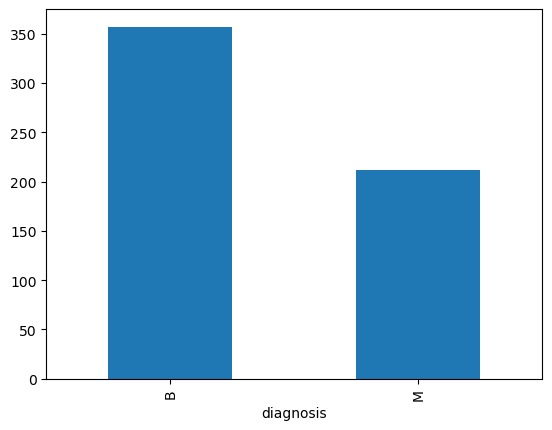

In [ ]:
data_diagnosis = data['diagnosis'].value_counts()
#print(data_diagnosis)
data_diagnosis.plot(kind='bar')

Видим дисбаланс классов.

In [ ]:
#from sklearn.preprocessing import LabelEncoder
#labelencoder = LabelEncoder()
from sklearn import preprocessing
label = preprocessing.LabelEncoder()
data['diagnosis'] = label.fit_transform(data['diagnosis'])
print(data['diagnosis'].unique())
#label.classes_

[1 0]


In [ ]:
data['diagnosis'].value_counts()

diagnosis
0    357
1    212
Name: count, dtype: int64

0 - "B" - доброкачесвтенный, 1 - "M" - злокачественный рак

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    int32  
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [ ]:
type(data['diagnosis']) #каждая колонка представляет из себя последовательность

pandas.core.series.Series

In [ ]:
data['diagnosis'].dtype

dtype('int32')

Видим, что столбец "diagnosis" стал в формате int32, целочисленный тип.

In [ ]:
#data = data.astype('int64')

При замене не считаталась корреляция во многих признаках, оставила float

## Проведем анализ корреляций признаков

In [ ]:
data = data.drop('id', axis = 1) #удалим не нужный столбец

<Axes: >

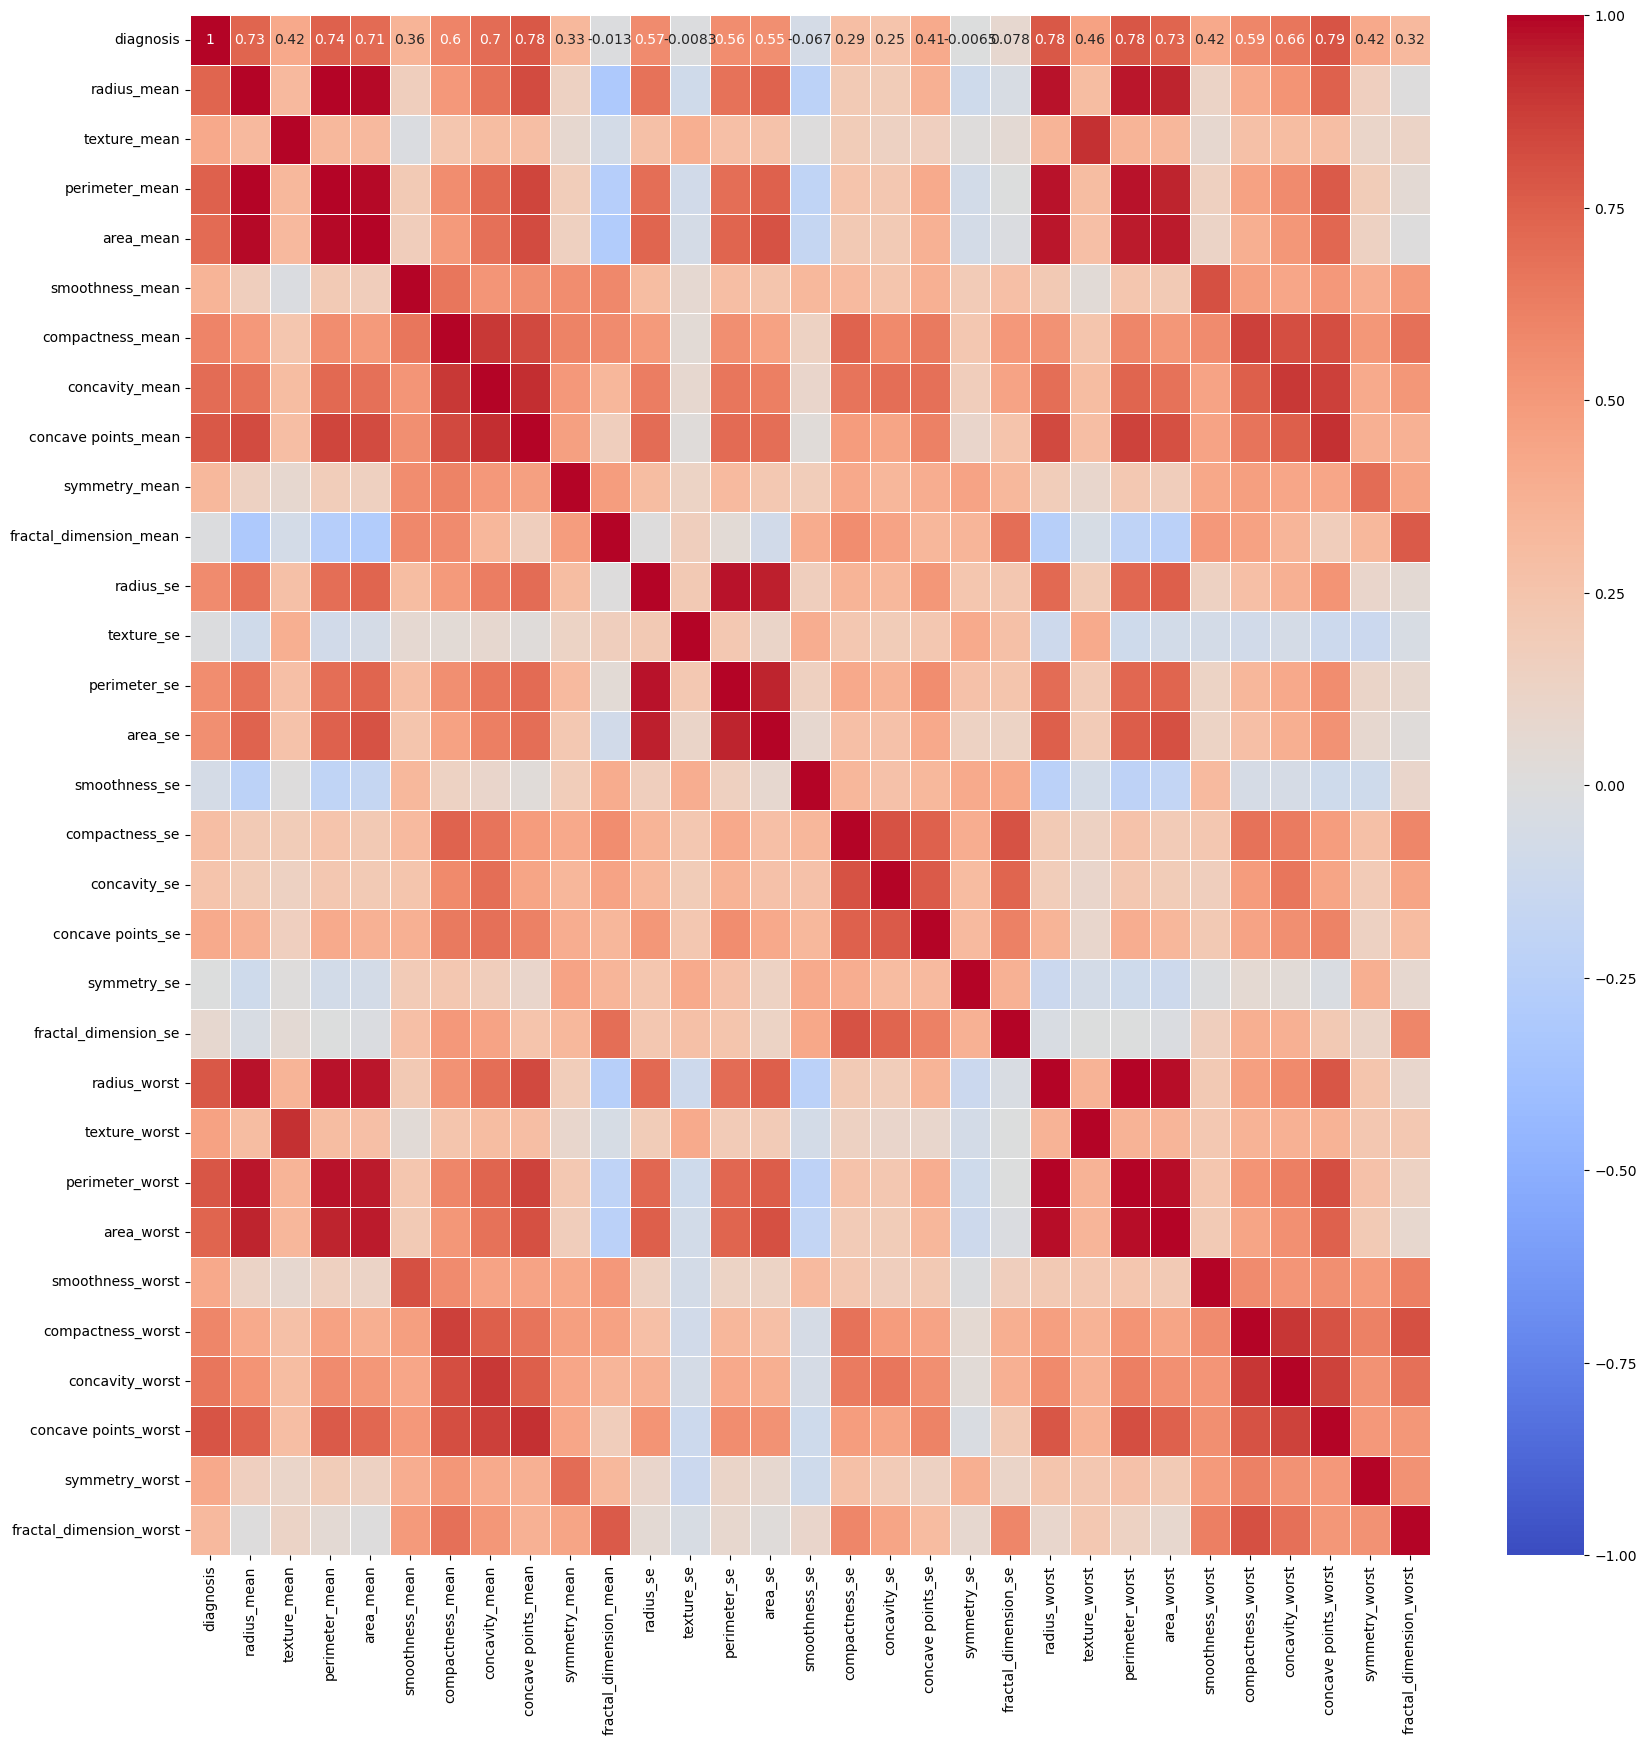

In [ ]:
plt.figure(figsize=(20, 20))
corr_mat = data.corr()
sns.heatmap(corr_mat, vmin=-1, vmax=1, cmap='coolwarm', annot= True, linewidths=0.5)

In [ ]:
#plt.figure(figsize=(20, 20))
#data_plot = sns.heatmap(data.corr(), cmap="YlGnBu", annot=True)
#plt.show()

In [ ]:
#data.corr()

In [ ]:
print(data.corr().iloc[:1])

           diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
diagnosis        1.0     0.730029      0.415185        0.742636   0.708984   

           smoothness_mean  compactness_mean  concavity_mean  \
diagnosis          0.35856          0.596534         0.69636   

           concave points_mean  symmetry_mean  ...  radius_worst  \
diagnosis             0.776614       0.330499  ...      0.776454   

           texture_worst  perimeter_worst  area_worst  smoothness_worst  \
diagnosis       0.456903         0.782914    0.733825          0.421465   

           compactness_worst  concavity_worst  concave points_worst  \
diagnosis           0.590998          0.65961              0.793566   

           symmetry_worst  fractal_dimension_worst  
diagnosis        0.416294                 0.323872  

[1 rows x 31 columns]


Зафиксируем, что такие признаки, как "radius_mean", "perimeter_mean", "area_mean", "concavity_mean", "concave points_mean", "radius_worst", "perimeter_worst", "area_worst", "concave points_worst" - имеют корреляцию с целевой переменной >= 0.7  


Нужно оценить какие признаки сильно коррелируют между собой, чтобы убрать/выкинуть некоторые признаки.  
Мультиколлинеарность — явление, при котором наблюдается сильная корреляция между признаками.  
*Коэффициент инфляции дисперсии или VIF — это мера, которая помогает обнаружить степень мультиколлинеарности в множественной регрессионной модели. Он показывает, насколько увеличивается дисперсия коэффициента оценки из-за линейной зависимости с другими предикторами.*

Выведем сильные корреляции и уберем их

In [ ]:
corr_result = data.corr()
corr_result = corr_result.stack()
corr_result[(corr_result != 1.0)&((corr_result > 0.9)|(corr_result < -0.9))]

radius_mean           perimeter_mean          0.997855
                      area_mean               0.987357
                      radius_worst            0.969539
                      perimeter_worst         0.965137
                      area_worst              0.941082
texture_mean          texture_worst           0.912045
perimeter_mean        radius_mean             0.997855
                      area_mean               0.986507
                      radius_worst            0.969476
                      perimeter_worst         0.970387
                      area_worst              0.941550
area_mean             radius_mean             0.987357
                      perimeter_mean          0.986507
                      radius_worst            0.962746
                      perimeter_worst         0.959120
                      area_worst              0.959213
concavity_mean        concave points_mean     0.921391
concave points_mean   concavity_mean          0.921391
          

Создадим новый датасет, где уберем сильно коррелирующие признаки (оставим один из двух).

In [ ]:
dataset = data.drop(columns=['perimeter_mean', 'area_mean','radius_worst','perimeter_worst','area_worst',
                            'texture_mean','concavity_mean','concave points_worst','radius_se','area_se']) #для 0.9
#display(dataset)
#display(data)

<Axes: >

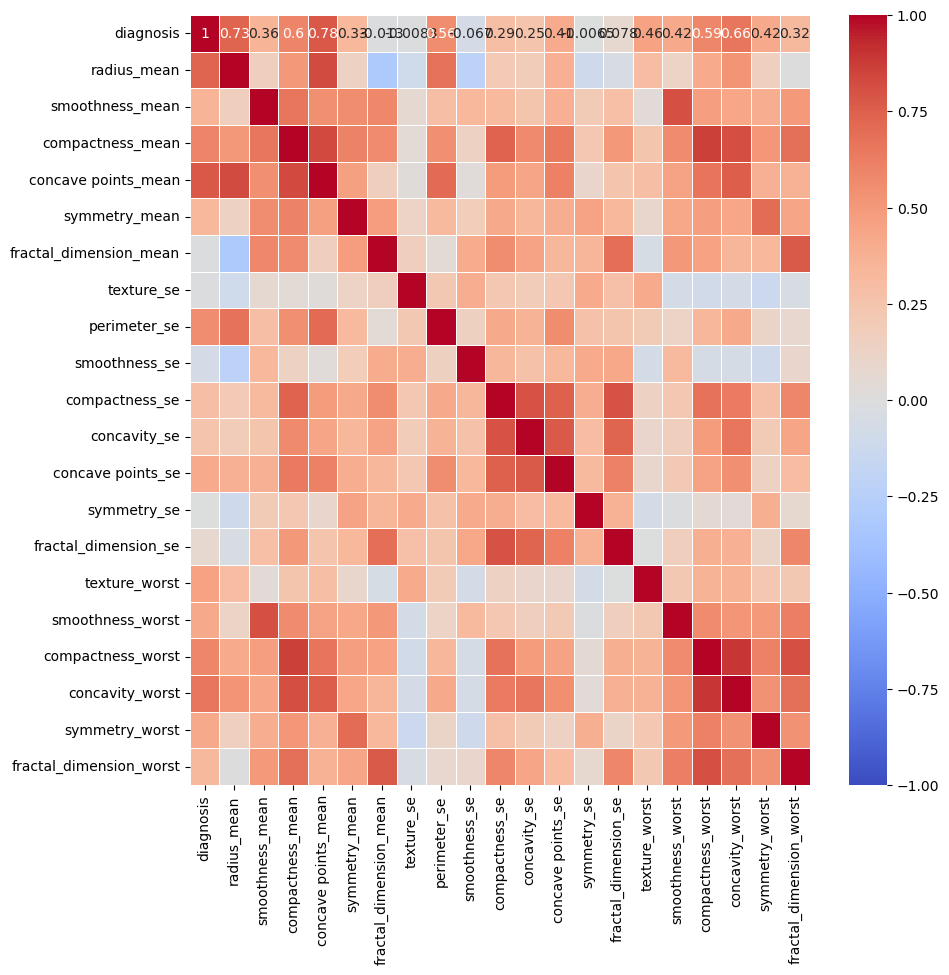

In [ ]:
plt.figure(figsize=(10, 10))
corr_mat_dataset = dataset.corr()
sns.heatmap(corr_mat_dataset, vmin=-1, vmax=1, cmap='coolwarm', annot= True, linewidths=0.5)

In [ ]:
corr_result = dataset.corr()
corr_result = corr_result.stack()
corr_result[(corr_result != 1.0)&((corr_result > 0.8)|(corr_result < -0.8))]

radius_mean              concave points_mean        0.822529
smoothness_mean          smoothness_worst           0.805324
compactness_mean         concave points_mean        0.831135
                         compactness_worst          0.865809
                         concavity_worst            0.816275
concave points_mean      radius_mean                0.822529
                         compactness_mean           0.831135
compactness_se           concavity_se               0.801268
                         fractal_dimension_se       0.803269
concavity_se             compactness_se             0.801268
fractal_dimension_se     compactness_se             0.803269
smoothness_worst         smoothness_mean            0.805324
compactness_worst        compactness_mean           0.865809
                         concavity_worst            0.892261
                         fractal_dimension_worst    0.810455
concavity_worst          compactness_mean           0.816275
                        

In [ ]:
dataset = dataset.drop(columns=['compactness_worst', 'concave points_mean', 'compactness_se',
                               'compactness_mean', 'concavity_worst', 'smoothness_mean']) # для 0.8

#plt.figure(figsize=(10, 10))
#corr_mat_dataset = dataset.corr()
#sns.heatmap(corr_mat_dataset, vmin=-1, vmax=1, cmap='coolwarm', annot= True, linewidths=0.5)

In [ ]:
corr_result = dataset.corr()
corr_result = corr_result.stack()
corr_result[(corr_result != 1.0)&((corr_result > 0.7)|(corr_result < -0.7))]

diagnosis                radius_mean                0.730029
radius_mean              diagnosis                  0.730029
fractal_dimension_mean   fractal_dimension_worst    0.767297
concavity_se             concave points_se          0.771804
                         fractal_dimension_se       0.727372
concave points_se        concavity_se               0.771804
fractal_dimension_se     concavity_se               0.727372
fractal_dimension_worst  fractal_dimension_mean     0.767297
dtype: float64

Признак "radius_mean" - имеет корреляцию с целевым признаком равную 0.73. Я его удалила, чтобы посмотреть на качество модели ниже (спойлер оно ухудшилось), затем вернула признак обратно.

In [ ]:
#dataset.drop(['symmetry_mean', 'fractal_dimension_se'], axis=1, inplace=True)

<Axes: >

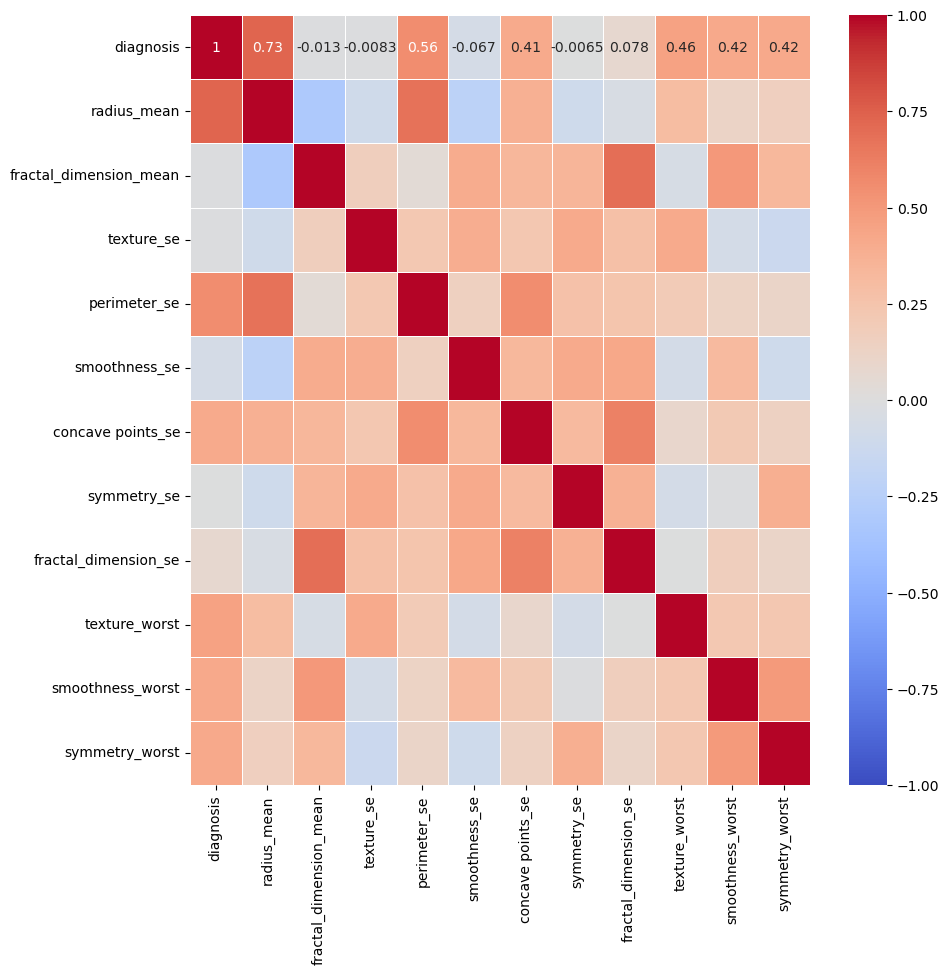

In [ ]:
dataset = dataset.drop(columns=['fractal_dimension_worst','concavity_se', 'symmetry_mean']) # для 0.7

plt.figure(figsize=(10, 10))
corr_mat_dataset = dataset.corr()
sns.heatmap(corr_mat_dataset, vmin=-1, vmax=1, cmap='coolwarm', annot= True, linewidths=0.5)

In [ ]:
corr_result = dataset.corr()
corr_result = corr_result.stack()
corr_result[(corr_result != 1.0)&((corr_result > 0.6)|(corr_result < -0.6))]

diagnosis               radius_mean               0.730029
radius_mean             diagnosis                 0.730029
                        perimeter_se              0.674172
fractal_dimension_mean  fractal_dimension_se      0.688132
perimeter_se            radius_mean               0.674172
concave points_se       fractal_dimension_se      0.611044
fractal_dimension_se    fractal_dimension_mean    0.688132
                        concave points_se         0.611044
dtype: float64

*Коэффициент инфляции дисперсии или VIF*  
Смысл этого метода и как вообще смотреть/убирать на мультиколлинеарные признаки взяла тут: https://www.kaggle.com/code/marcinrutecki/multicollinearity-detection-and-remedies

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

X = add_constant(data)
VIFs = pd.DataFrame()
VIFs['Variable'] = X.columns
VIFs['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(VIFs)


                   Variable          VIF
0                     const  1945.673866
1                 diagnosis     4.431144
2               radius_mean  3817.259795
3              texture_mean    11.891280
4            perimeter_mean  3792.697001
5                 area_mean   348.115385
6           smoothness_mean     8.194309
7          compactness_mean    51.445960
8            concavity_mean    71.002747
9       concave points_mean    60.172431
10            symmetry_mean     4.220806
11   fractal_dimension_mean    15.756978
12                radius_se    75.737325
13               texture_se     4.205686
14             perimeter_se    70.398925
15                  area_se    41.196467
16            smoothness_se     4.070801
17           compactness_se    15.366350
18             concavity_se    15.914022
19        concave points_se    11.601253
20              symmetry_se     5.179151
21     fractal_dimension_se     9.724753
22             radius_worst   815.945630
23            te

## Отделение train от test, а целевой переменной от признаков, а также valid

Hазделиv выборки на обучающую (60%), валидационную (20%) и тестовую (20%).

In [ ]:
from sklearn.model_selection import train_test_split
data_train, data_test1 = train_test_split(data, test_size=0.4, random_state=RANDOM_STATE, stratify=data['diagnosis'])
data_test, data_valid = train_test_split(data_test1, test_size=0.5, random_state=RANDOM_STATE, stratify=data_test1['diagnosis'])
print(data_train.shape)
print(data_test.shape)
print(data_valid.shape)

(341, 31)
(114, 31)
(114, 31)


In [ ]:
target_train = data_train['diagnosis']
features_train = data_train.drop('diagnosis', axis=1)
target_valid = data_valid['diagnosis']
features_valid = data_valid.drop('diagnosis', axis=1)
target_test = data_test['diagnosis']
features_test = data_test.drop('diagnosis', axis=1)

print(f'features_train: {features_train.shape}\ntarget_train: {target_train.shape}\nfeatures_valid: {features_valid.shape}\ntarget_valid{target_valid.shape}\
                        \nfeatures_test: {features_test.shape}\ntarget_test: {target_test.shape}')

features_train: (341, 30)
target_train: (341,)
features_valid: (114, 30)
target_valid(114,)                        
features_test: (114, 30)
target_test: (114,)


Разделим датафреймы на train/test в соотношении 80/20%

In [ ]:
X = data.drop('diagnosis', axis=1)
y = data['diagnosis']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=RANDOM_STATE, stratify=y)
print(f'X_train: {X_train.shape}\nX_test: {X_test.shape}\ny_train: {y_train.shape}\ny_test: {y_test.shape}')

X_train: (455, 30)
X_test: (114, 30)
y_train: (455,)
y_test: (114,)


Также разделим и тот датасет, где будут удалены высоко коррелированные признаки

In [ ]:
X_corr = dataset.drop('diagnosis', axis=1)
y_corr = dataset['diagnosis']
X_train_corr, X_test_corr, y_train_corr, y_test_corr = train_test_split(X_corr, y_corr, test_size=0.2,random_state=RANDOM_STATE, stratify=y_corr)
print(f'X_train_corr: {X_train_corr.shape}\nX_test_corr: {X_test_corr.shape}\ny_train_corr: {y_train_corr.shape}\ny_test_corr: {y_test_corr.shape}')

X_train_corr: (455, 11)
X_test_corr: (114, 11)
y_train_corr: (455,)
y_test_corr: (114,)


Сохраним датасет в без стандартизации данных и с удаленными признаками. Нам это понадобится для деревянных моделей. И для градиентного бустинга.

In [ ]:
X_tree = dataset.drop('diagnosis', axis=1)
y_tree = dataset['diagnosis']
X_train_tree, X_test_tree, y_train_tree, y_test_tree = train_test_split(X_tree, y_tree, test_size=0.2,random_state=RANDOM_STATE, stratify=y_tree)
print(f'X_train_tree: {X_train_tree.shape}\nX_test_tree: {X_test_tree.shape}\ny_train_tree: {y_train_tree.shape}\ny_test_tree: {y_test_tree.shape}')

X_train_tree: (455, 11)
X_test_tree: (114, 11)
y_train_tree: (455,)
y_test_tree: (114,)


## Стандартизация числовых признаков

Приведем признаки к единому масштабу.

Cледует закодировать все признаки + применить minmaxscaler.  

*Нормализация помогает, чтобы алгоритмы машинного обучения не были предвзяты к переменным с большими значениями. Этот метод предварительной обработки полезен при работе с алгоритмами, чувствительными к масштабу признаков, например, k-ближайшими соседями и нейронными сетями.*
*MinMaxScaler не уменьшает влияние выбросов, а линейно масштабирует их в фиксированный диапазон, где самая большая точка данных соответствует максимальному значению, а самая маленькая — минимальному.*

X_train = pd.DataFrame(transformer.transform(X_train), columns=transformer.get_feature_names_out())
X_test = pd.DataFrame(transformer.transform(X_test), columns=transformer.get_feature_names_out())

In [ ]:
from sklearn.preprocessing import StandardScaler # средний 0, а разброс стандратных отклонений = 1 (смотрим по mean, кто больше всего разнится)
from sklearn.compose import make_column_transformer

transformer = StandardScaler()
transformer.fit(X_train)

X_train = pd.DataFrame(transformer.transform(X_train), columns=transformer.get_feature_names_out())
X_test = pd.DataFrame(transformer.transform(X_test), columns=transformer.get_feature_names_out())

In [ ]:
X_train.mean()

radius_mean                4.138326e-16
texture_mean               4.489693e-16
perimeter_mean            -4.450652e-16
area_mean                  0.000000e+00
smoothness_mean           -1.952040e-16
compactness_mean          -2.147245e-16
concavity_mean             2.537653e-16
concave points_mean        3.904081e-18
symmetry_mean              8.823223e-16
fractal_dimension_mean     8.628019e-16
radius_se                  5.270509e-17
texture_se                 4.021203e-16
perimeter_se               2.108204e-16
area_se                   -1.132183e-16
smoothness_se             -1.795877e-16
compactness_se            -1.522592e-16
concavity_se              -2.732857e-17
concave points_se         -1.522592e-16
symmetry_se               -5.660917e-16
fractal_dimension_se       9.760202e-18
radius_worst               2.342449e-17
texture_worst              7.027346e-17
perimeter_worst            4.684897e-17
area_worst                 1.171224e-16
smoothness_worst          -7.339672e-16


<Axes: >

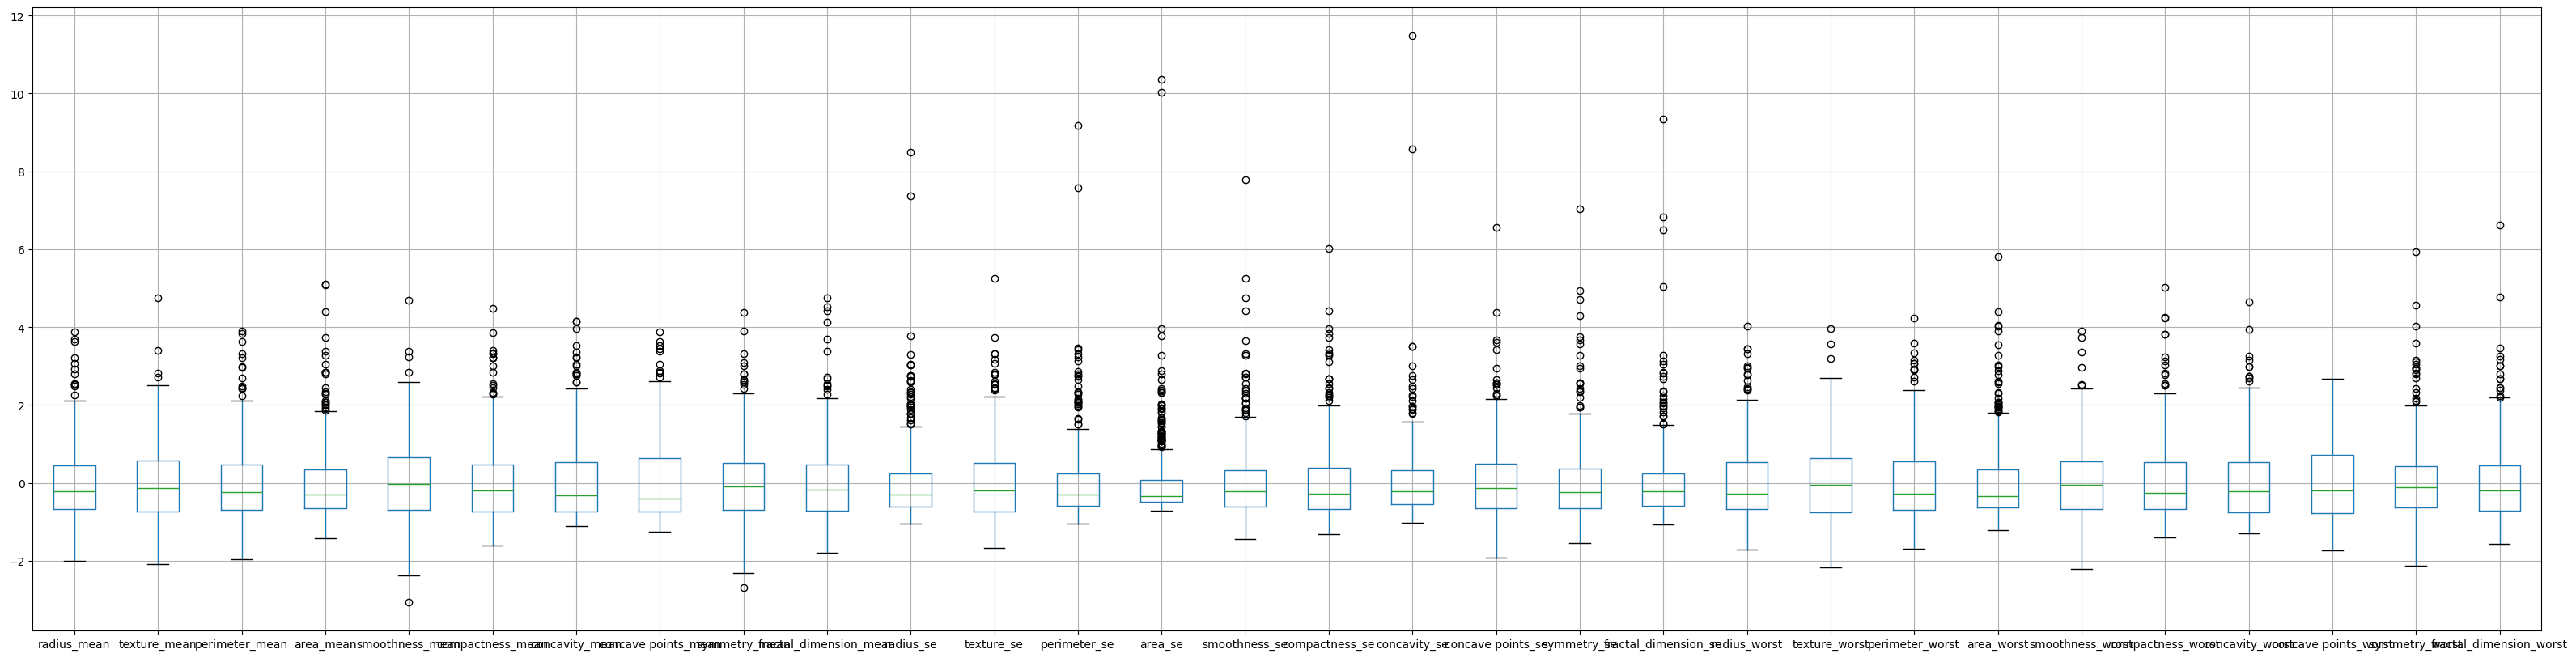

In [ ]:
X_train.boxplot(column=['radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'], figsize=(40,10))

Видим, что у некоторых признаков имеются выбросы. Проведем minmaxscaler.

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaled_data = scaler.fit(X_train)

X_train = pd.DataFrame(scaled_data.transform(X_train), columns=scaler.get_feature_names_out())
X_test = pd.DataFrame(scaled_data.transform(X_test), columns=scaler.get_feature_names_out())

<Axes: >

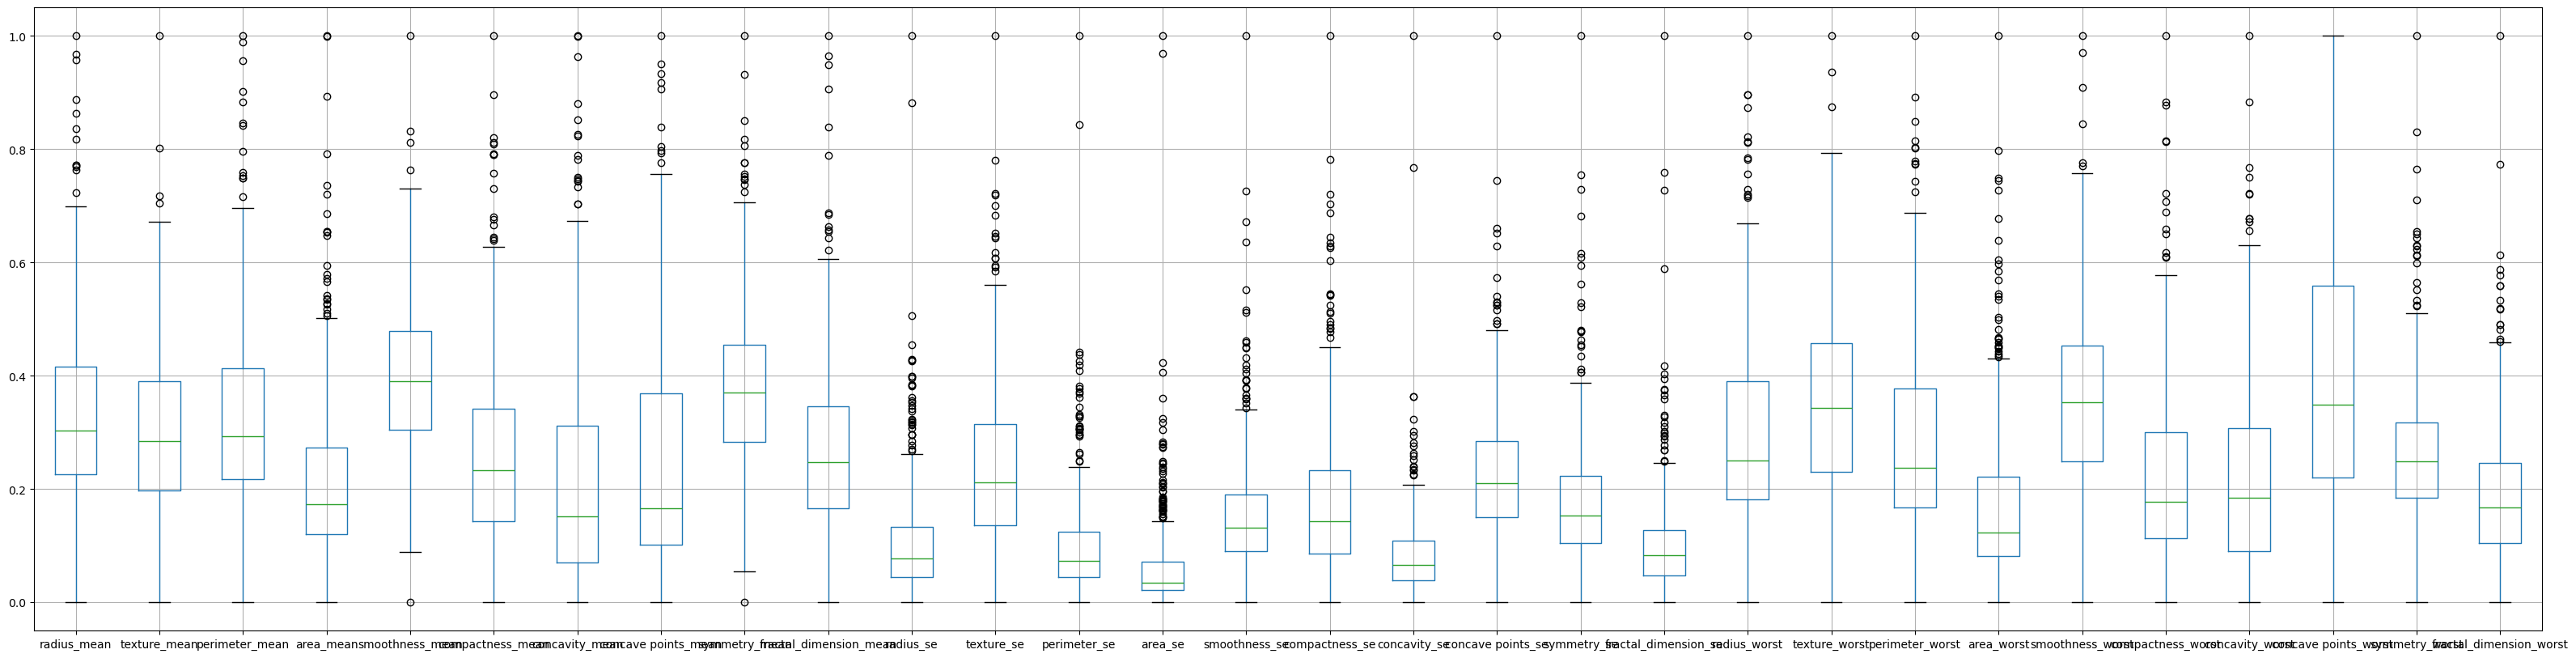

In [ ]:
X_train.boxplot(column=['radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'], figsize=(40,10))

In [ ]:
X_train.describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,455.000000,455.000000,455.000000,455.000000,455.000000,455.000000,455.000000,455.000000,455.000000,455.000000,...,455.000000,455.000000,455.000000,455.000000,455.000000,455.000000,455.000000,455.000000,455.000000,455.000000
mean,0.339440,0.305475,0.334216,0.218499,0.395196,0.264552,0.211228,0.244995,0.380953,0.273123,...,0.297983,0.352718,0.284401,0.172133,0.360335,0.218023,0.218635,0.394370,0.263520,0.191261
std,0.170331,0.146322,0.171222,0.153566,0.129125,0.163922,0.190322,0.195216,0.141401,0.153225,...,0.174249,0.163640,0.169000,0.142686,0.163944,0.156085,0.168243,0.227234,0.124257,0.122126
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.225235,0.197405,0.217504,0.119979,0.304776,0.143580,0.070080,0.101069,0.282576,0.165227,...,0.181786,0.230904,0.167962,0.081265,0.248674,0.112613,0.090296,0.220189,0.184900,0.104158
50%,0.302854,0.284775,0.293345,0.172895,0.390810,0.233360,0.151734,0.166501,0.369697,0.246841,...,0.250800,0.343320,0.236815,0.123722,0.353378,0.177282,0.183866,0.348797,0.248571,0.167126
75%,0.415732,0.389619,0.413655,0.273001,0.479101,0.340991,0.311504,0.368265,0.454293,0.346356,...,0.390075,0.456680,0.376961,0.221392,0.452423,0.300172,0.306789,0.558935,0.317761,0.246097
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Удоствоерились, что метод сработал.

In [ ]:
transformer = StandardScaler()
transformer.fit(X_train_corr)

X_train_corr = pd.DataFrame(transformer.transform(X_train_corr), columns=transformer.get_feature_names_out())
X_test_corr = pd.DataFrame(transformer.transform(X_test_corr), columns=transformer.get_feature_names_out())

scaler = MinMaxScaler()
scaled_data = scaler.fit(X_train_corr)

X_train_corr = pd.DataFrame(scaled_data.transform(X_train_corr), columns=scaler.get_feature_names_out())
X_test_corr = pd.DataFrame(scaled_data.transform(X_test_corr), columns=scaler.get_feature_names_out())

In [ ]:
X_train_corr.describe()

,radius_mean,fractal_dimension_mean,texture_se,perimeter_se,smoothness_se,concave points_se,symmetry_se,fractal_dimension_se,texture_worst,smoothness_worst,symmetry_worst
count,455.000000,455.000000,455.000000,455.000000,455.000000,455.000000,455.000000,455.000000,455.000000,455.000000,455.000000
mean,0.339440,0.273123,0.240582,0.102114,0.155722,0.226683,0.179875,0.102901,0.352718,0.360335,0.263520
std,0.170331,0.153225,0.144639,0.098024,0.108600,0.118097,0.116591,0.096204,0.163640,0.163944,0.124257
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.225235,0.165227,0.135969,0.043797,0.089555,0.150796,0.103886,0.047113,0.230904,0.248674,0.184900
50%,0.302854,0.246841,0.211919,0.073270,0.132277,0.210267,0.153487,0.083060,0.343320,0.353378,0.248571
75%,0.415732,0.346356,0.314780,0.125100,0.190581,0.284618,0.223490,0.127023,0.456680,0.452423,0.317761
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
X_train_corr.columns

Index(['radius_mean', 'fractal_dimension_mean', 'texture_se', 'perimeter_se',
       'smoothness_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'texture_worst', 'smoothness_worst',
       'symmetry_worst'],
      dtype='object')

<Axes: >

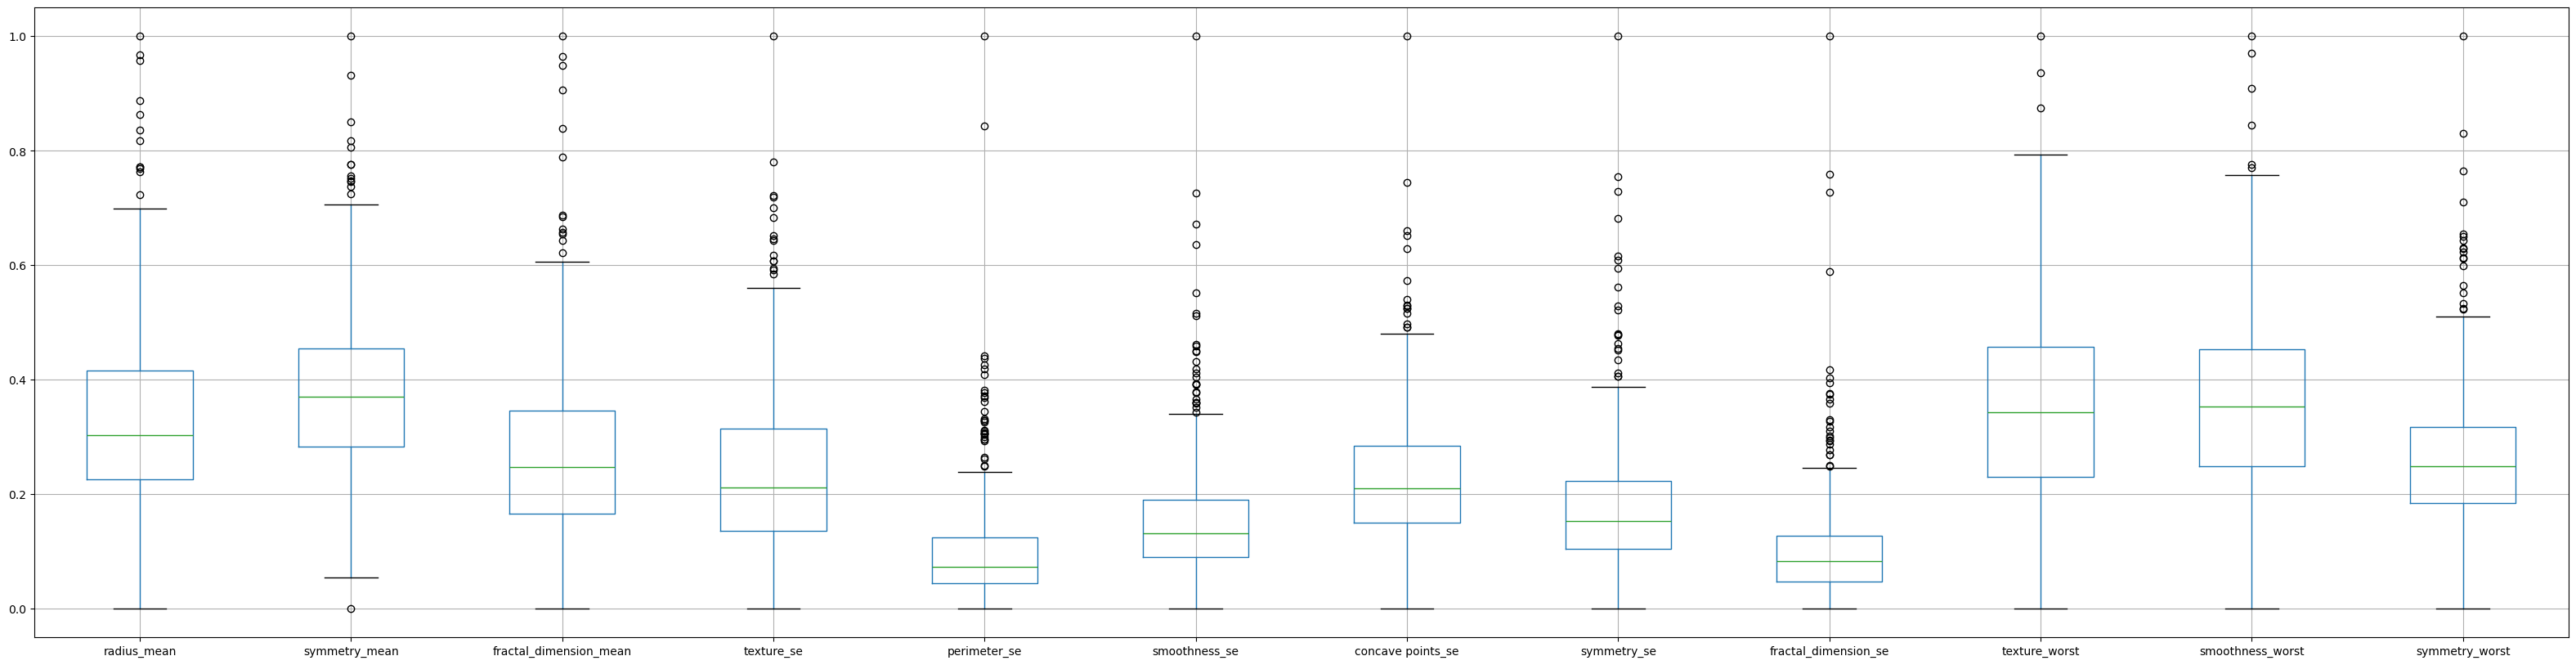

In [ ]:
X_train.boxplot(column=['radius_mean', 'symmetry_mean', 'fractal_dimension_mean', 'texture_se',
       'perimeter_se', 'smoothness_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'texture_worst', 'smoothness_worst',
       'symmetry_worst'], figsize=(40,10))

Проделаем тоже самое, но для выборок train test valid.

In [ ]:
transformer = StandardScaler()
transformer.fit(features_train)

features_train = pd.DataFrame(transformer.transform(features_train), columns=transformer.get_feature_names_out())
features_test = pd.DataFrame(transformer.transform(features_test), columns=transformer.get_feature_names_out())
features_valid = pd.DataFrame(transformer.transform(features_valid), columns=transformer.get_feature_names_out())

In [ ]:
features_train.mean()

radius_mean               -6.772035e-17
texture_mean              -2.044634e-16
perimeter_mean            -1.198129e-16
area_mean                 -2.604629e-18
smoothness_mean           -6.407387e-16
compactness_mean           9.897589e-17
concavity_mean            -1.510685e-16
concave points_mean       -1.041852e-17
symmetry_mean             -6.199017e-16
fractal_dimension_mean    -1.666962e-16
radius_se                 -2.630675e-16
texture_se                -2.995323e-16
perimeter_se              -2.604629e-17
area_se                   -4.167406e-17
smoothness_se              7.813886e-17
compactness_se             1.562777e-17
concavity_se               6.251109e-17
concave points_se         -3.516249e-16
symmetry_se                1.510685e-16
fractal_dimension_se       1.041852e-17
radius_worst               3.750665e-16
texture_worst             -5.209258e-18
perimeter_worst            4.115313e-16
area_worst                 1.302314e-16
smoothness_worst          -5.573906e-16


<Axes: >

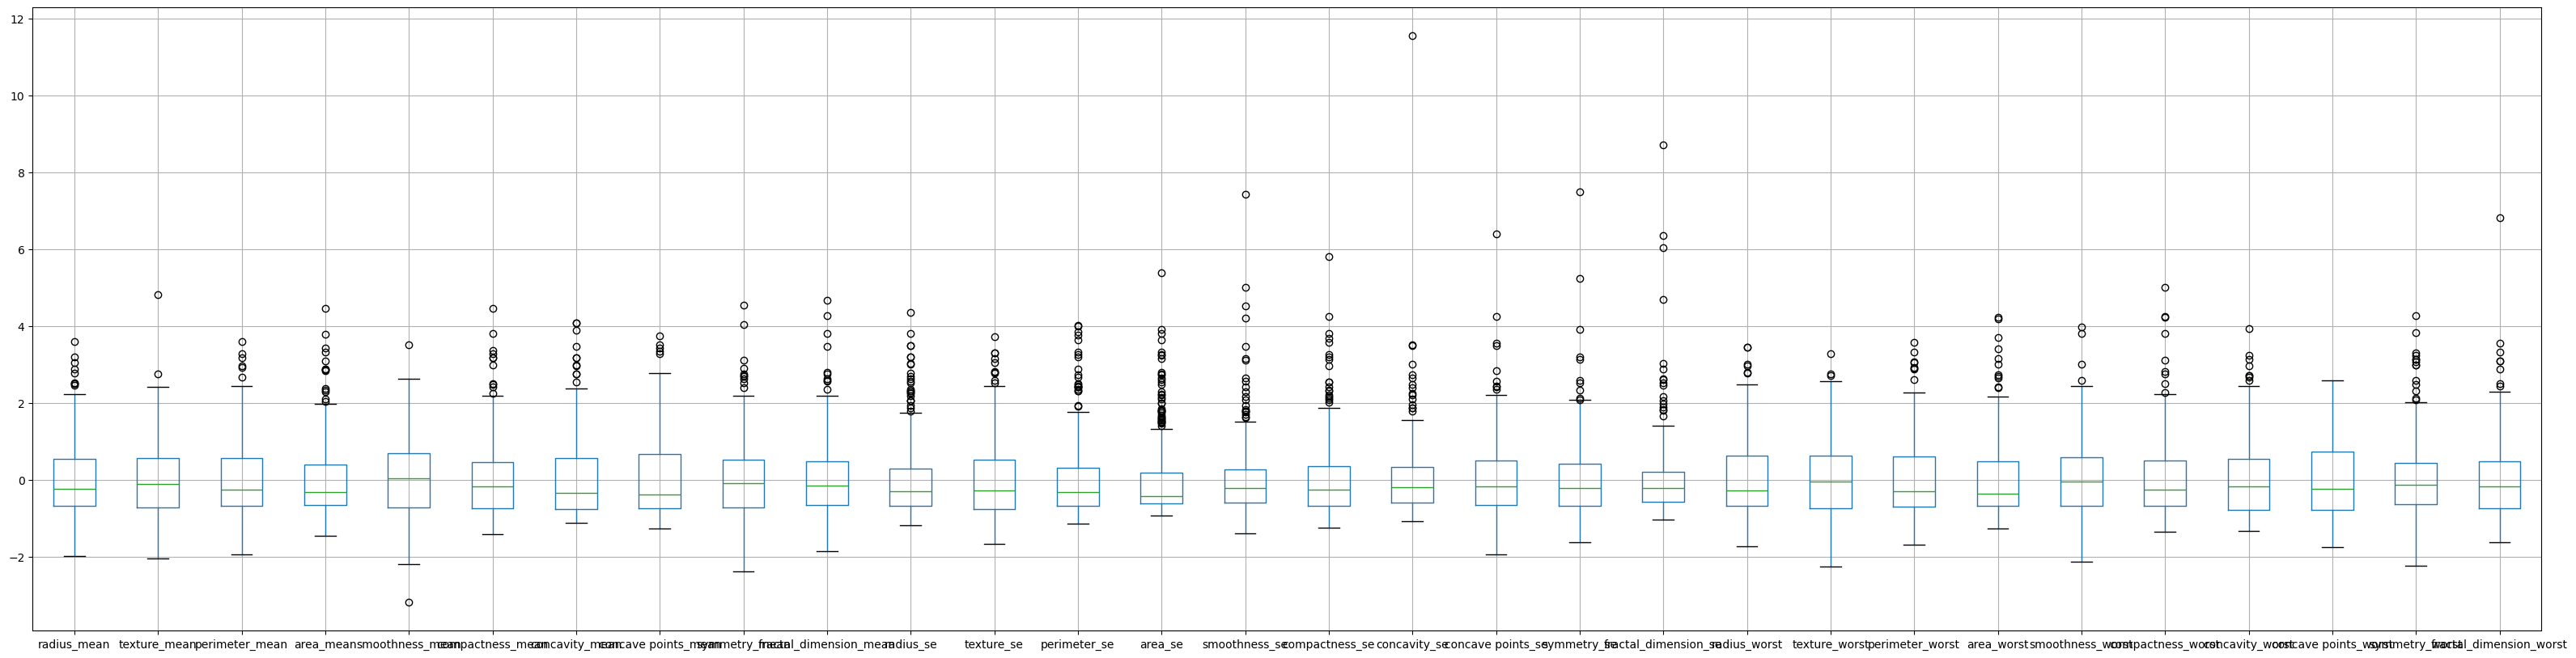

In [ ]:
features_train.boxplot(column=['radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'], figsize=(40,10))

In [ ]:
scaler = MinMaxScaler()
scaled_data = scaler.fit(features_train)

features_train = pd.DataFrame(scaled_data.transform(features_train), columns=scaled_data.get_feature_names_out())
features_test = pd.DataFrame(scaled_data.transform(features_test), columns=scaled_data.get_feature_names_out())
features_valid = pd.DataFrame(scaled_data.transform(features_valid), columns=scaled_data.get_feature_names_out())

<Axes: >

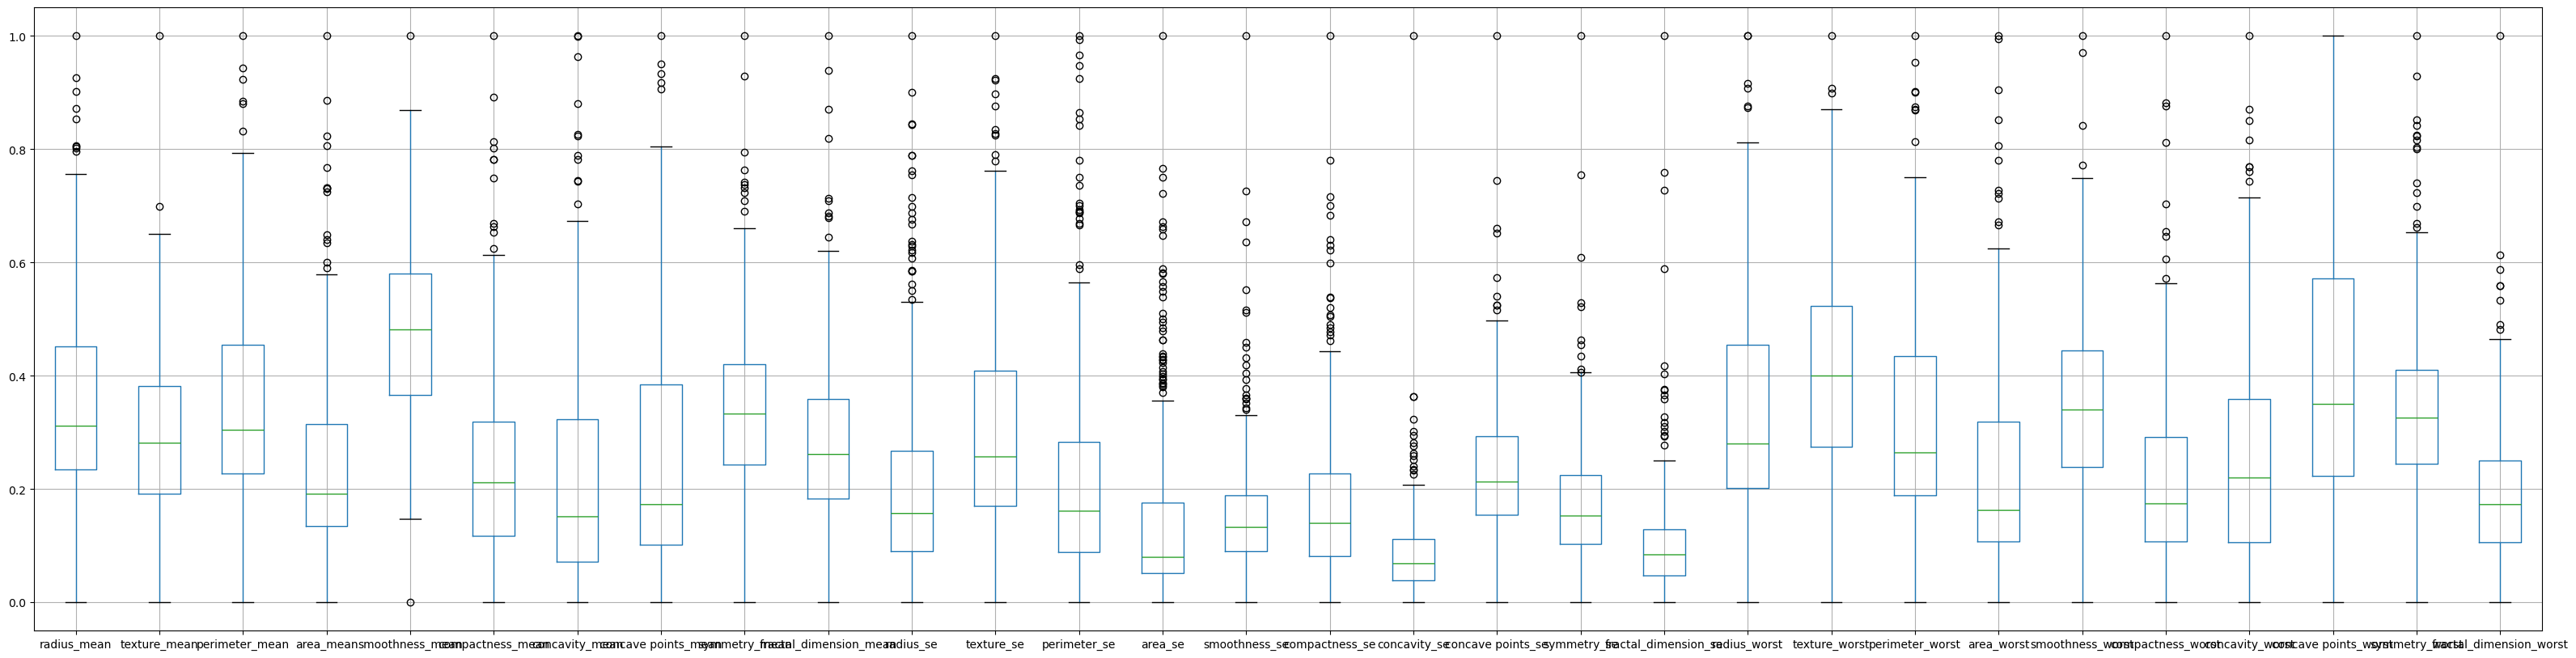

In [ ]:
features_train.boxplot(column=['radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'], figsize=(40,10))

In [ ]:
#features_train.describe()

# Обучение моделей

## LogisticRegression model

Мы решаем задачу классификации.

Сначала обучим логистическую регрессию.

In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(random_state=RANDOM_STATE)
model.fit(X_train, y_train)
predictions_test = model.predict(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression
model_corr = LogisticRegression(random_state=RANDOM_STATE)
model_corr.fit(X_train_corr, y_train_corr)
predictions_test_corr = model_corr.predict(X_test_corr)

In [ ]:
predictions_test

array([0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0,
       1, 1, 0, 0])

Построим матрицу ошибок

[[72  0]
 [ 3 39]]


Text(50.722222222222214, 0.5, 'Actual')

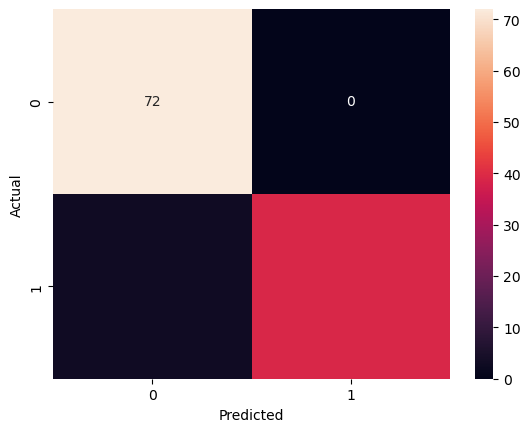

In [ ]:
from sklearn.metrics import confusion_matrix
conf_matrix = confusion_matrix(y_test, predictions_test)
print(conf_matrix) #  сначала идут истинные значение, затем предсказанные

sns.heatmap(conf_matrix, annot=True)
plt.xlabel('Predicted') # По оси Y идёт реальная метка класса, по оси X — предсказанная.
plt.ylabel('Actual')

0 -  доброкачесвтенный, 1 - злокачественный рак.
72 человек человек были предсказаны корректно/верно (добро было, добро и предсказано) (TN), 0 человек (FP) - предсказали что зло, а на самом деле было добро.
Есть злокачественное новообразование молочки у человека - 3 (FN) человек не были предсказаны что у них зло, а 39 (TP) предсказаны что есть злокач. рак. он и был.

При выкидывании нескольких признак видим, что логистическая регрессия дала:  

[[72  0]
 [ 7 35]]


Text(50.722222222222214, 0.5, 'Actual')

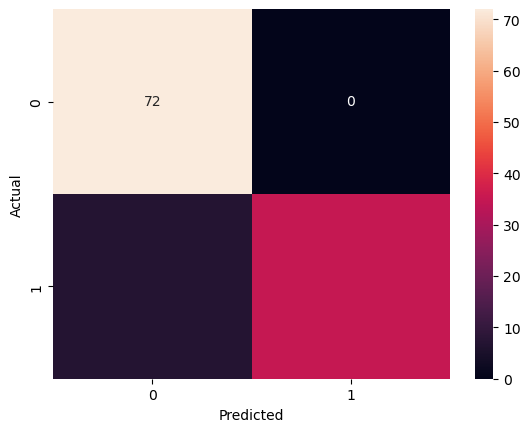

In [ ]:
#from sklearn.metrics import confusion_matrix
conf_matrix_corr = confusion_matrix(y_test_corr, predictions_test_corr)
print(conf_matrix_corr) #  сначала идут истинные значение, затем предсказанные

sns.heatmap(conf_matrix_corr, annot=True)
plt.xlabel('Predicted') # По оси Y идёт реальная метка класса, по оси X — предсказанная.
plt.ylabel('Actual')

72 xеловек человек были предсказаны корректно/верно (добро было, добро и предсказано) (TN), 0 человек (FP) - предсказали что зло, а на самом деле было добро.
Есть злокачественное новообразование молочки у человека - 7 (FN) человек не были предсказаны что у них зло, а 35 (TP) предсказаны что есть злокач. рак. он и был.  
Выходит матрица ошибок стала чуть хуже

Вычислим долю правильных ответов:

In [ ]:
from sklearn.metrics import accuracy_score
acc_LR = accuracy_score(y_test, predictions_test)
print(f'accuracy LogisticRegression for test = {acc_LR}')

accuracy LogisticRegression for test = 0.9736842105263158


In [ ]:
from sklearn.metrics import accuracy_score
acc_LR_corr = accuracy_score(y_test_corr, predictions_test_corr)
print(f'accuracy LogisticRegression for test = {acc_LR_corr}')

accuracy LogisticRegression for test = 0.9385964912280702


Также видим, что уменьшилась метрика accuracy у датасета, где убраны некоторые коррелирующие признаки.

Посмотрим на баланс классов в датасете.

diagnosis
0    357
1    212
Name: count, dtype: int64


<Axes: xlabel='diagnosis'>

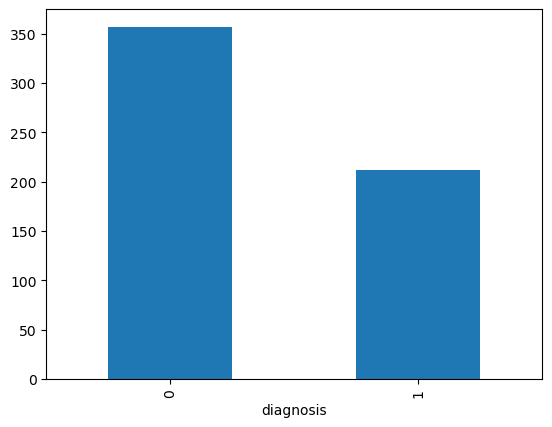

In [ ]:
print(y.value_counts()) # y - это target, забываю...
y.value_counts().plot(kind='bar')

В данных 357 человек с доброкачественным раком, а 212 со злом. Наблюдаем дисбаланс классов, значит надо воспользоваться метрикой, которая это учитывает (воспользоваться сбалансированной долей правильных ответов).

In [ ]:
from sklearn.metrics import balanced_accuracy_score
print('Balanced accuracy LogisticRegression =', balanced_accuracy_score(y_test, predictions_test))
print('Balanced accuracy LogisticRegression_corr =', balanced_accuracy_score(y_test_corr, predictions_test_corr))

Balanced accuracy LogisticRegression = 0.9642857142857143
Balanced accuracy LogisticRegression_corr = 0.9166666666666667


Вышло немного меньше: 0.97 > 0.96 у датасета, где используем все признаки.  
У датасета с убранными признаками: 0.94 > 0.928- вышло тоже меньше, но все равно точность все еще высокая.

In [ ]:
acc_balance_LR_corr = balanced_accuracy_score(y_test_corr, predictions_test_corr)
print(acc_balance_LR_corr)

0.9166666666666667


Посчитаем точность, полноту, F1-оценку для LogisticRegression.  
precision - доля правлильно предсказанных положительных объектов. recall - какую долю всех объектов на которых классификатор должен был сработать, на какую долю объектов он сработал в действительности. f1_score - это средняя от precision и recall, для баланса между точностью и полнотой и охарактиризовать все единой характеристикой.

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

print('Precision', precision_score(y_test, predictions_test))
print('Recall',       recall_score(y_test, predictions_test))
print('F1-score',         f1_score(y_test, predictions_test))

Precision 1.0
Recall 0.9285714285714286
F1-score 0.962962962962963


In [ ]:
print('Precision_corr', precision_score(y_test_corr, predictions_test_corr))
print('Recall_corr',       recall_score(y_test_corr, predictions_test_corr))
print('F1-score_corr',         f1_score(y_test_corr, predictions_test_corr))

Precision_corr 1.0
Recall_corr 0.8333333333333334
F1-score_corr 0.9090909090909091


recall у датасета без части признаков - значительно уменьшился.

In [ ]:
Precision_corr_LR = precision_score(y_test_corr, predictions_test_corr)
Recall_corr_LR = recall_score(y_test_corr, predictions_test_corr)
F1_score_corr_LR = f1_score(y_test_corr, predictions_test_corr)

#print(Precision_corr_LR, Recall_corr_LR, F1_score_corr_LR)

Попробуем "Степень уверенности классификатора". Сделаем так, что будем в задаче классификации предсказывать не просто метку класса, а степень уверенности (вероятность) того, что объект принадлежит определённому классу (каком-то роде задача ранжирования объектов).

In [ ]:
predictions_probs_test = model.predict_proba(X_test)
print('Тип объекта:', type(predictions_probs_test))
print('Размер матрицы:', predictions_probs_test.shape)
print('Тип элементов матрицы:', predictions_probs_test.dtype)

Тип объекта: <class 'numpy.ndarray'>
Размер матрицы: (114, 2)
Тип элементов матрицы: float64


In [ ]:
predictions_probs_test_corr = model_corr.predict_proba(X_test_corr)
print('Тип объекта:', type(predictions_probs_test_corr))
print('Размер матрицы:', predictions_probs_test_corr.shape)
print('Тип элементов матрицы:', predictions_probs_test_corr.dtype)

Тип объекта: <class 'numpy.ndarray'>
Размер матрицы: (114, 2)
Тип элементов матрицы: float64


114 объектов, 2 класса

In [ ]:
print(model.classes_)

[0 1]


In [ ]:
#print(model_corr.classes_)

Сначала класс 0 - доброкачесвтенный рак на (0-м месте в массиве), потом класс 1 - злокачесвтенный рак (1-м месте в массиве).  
Если хотим найти людей со злом - смотри на 1-ю колонку.

In [ ]:
predictions_test

array([0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0,
       1, 1, 0, 0])

In [ ]:
print('Probabilities', predictions_probs_test)

Probabilities [[9.76917057e-01 2.30829434e-02]
 [5.74012628e-03 9.94259874e-01]
 [9.43506000e-01 5.64940001e-02]
 [6.39870915e-02 9.36012909e-01]
 [7.78981908e-01 2.21018092e-01]
 [1.73431487e-01 8.26568513e-01]
 [9.26533213e-01 7.34667869e-02]
 [6.45207163e-01 3.54792837e-01]
 [9.74339012e-01 2.56609878e-02]
 [1.45306083e-01 8.54693917e-01]
 [6.94400706e-01 3.05599294e-01]
 [9.36706667e-01 6.32933332e-02]
 [5.15573233e-01 4.84426767e-01]
 [2.26156210e-03 9.97738438e-01]
 [2.82183350e-01 7.17816650e-01]
 [1.74362378e-01 8.25637622e-01]
 [9.92424278e-01 7.57572150e-03]
 [9.42120385e-01 5.78796154e-02]
 [9.60437766e-01 3.95622341e-02]
 [6.85049523e-01 3.14950477e-01]
 [3.93310623e-02 9.60668938e-01]
 [9.07316891e-01 9.26831094e-02]
 [9.81077849e-01 1.89221506e-02]
 [4.86853334e-01 5.13146666e-01]
 [8.99546809e-01 1.00453191e-01]
 [9.93680677e-01 6.31932258e-03]
 [9.34603519e-01 6.53964807e-02]
 [9.65185367e-01 3.48146328e-02]
 [7.79319666e-01 2.20680334e-01]
 [9.04695503e-01 9.53044971e-

## Метрики ранжирования классификатора по степени уверенности.   
Посчитаем теперь метрики полученного ранжирования: площади под ROC- и PR-кривыми. Площадь под ROC кривой и площадь под precision recall (среднее значение точности).

In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score
roc_auc = roc_auc_score(y_test, predictions_probs_test[:, 1])
pr_auc = average_precision_score(y_test, predictions_probs_test[:, 1])
print(f'ROC AUC: {roc_auc}')
print(f'PR AUC: {pr_auc}')

ROC AUC: 1.0
PR AUC: 1.0


PR AUC, площадь под Precision-Recall кривой (она же average precision, AP) — средняя точность классификатора при разных значениях полноты. Эта метрика лучше работает в ситуации сильного дисбаланса классов.

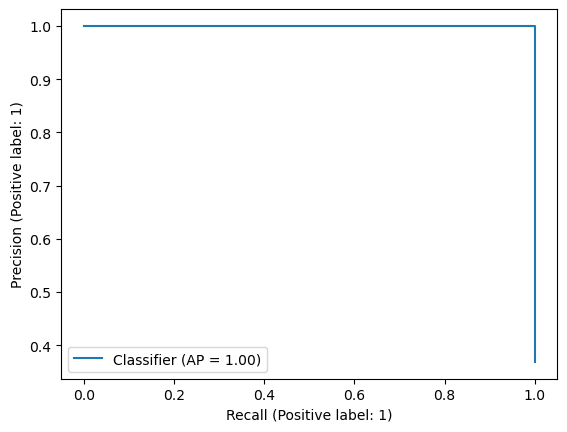

In [ ]:
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import PrecisionRecallDisplay
PrecisionRecallDisplay.from_predictions(y_test, predictions_probs_test[:, 1])

ROC AUC: 0.99, PR AUC: 0.99 - слишком подозрительно высокие значения метрик, это слишком хорошо

Сделаем тоже самое с данными без части признаков:

In [ ]:
roc_auc_corr_LR = roc_auc_score(y_test_corr, predictions_probs_test_corr[:, 1])
pr_auc_corr_LR = average_precision_score(y_test_corr, predictions_probs_test_corr[:, 1])
print(f'ROC AUC: {roc_auc_corr_LR}')
print(f'PR AUC: {pr_auc_corr_LR}')

ROC AUC: 0.9970238095238095
PR AUC: 0.9947892791304676


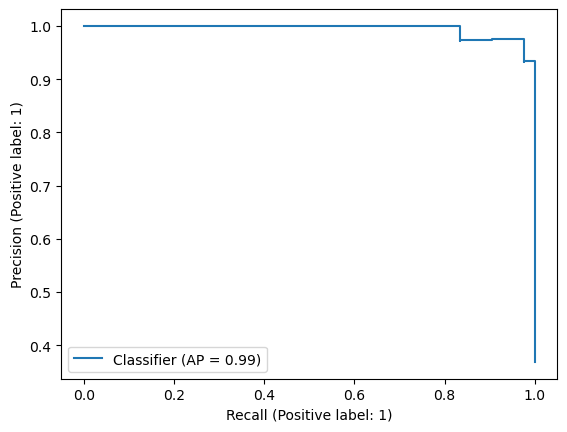

In [ ]:
PrecisionRecallDisplay.from_predictions(y_test_corr, predictions_probs_test_corr[:, 1])

Тоже видим хорошие значения метрик.

## Проведем подбор гиперпараметров.

Отключим штраф (отключим регуляризацию).

In [ ]:
model_corr = LogisticRegression(penalty=None, random_state=RANDOM_STATE)
model_corr.fit(X_train_corr, y_train_corr)

print('Accuracy', accuracy_score(y_test_corr, model_corr.predict(X_test_corr)))
print('F1-score', f1_score(y_test_corr, model_corr.predict(X_test_corr)))

Accuracy 0.9912280701754386
F1-score 0.9879518072289156


Качество улучшилось (было `F1-score_corr 0.90` и `Balanced accuracy LogisticRegression_arr = 0.93`), но это может быть элементом случайности.

Проведем кроссвалидацию.

In [ ]:
from sklearn.linear_model import LogisticRegressionCV

model_corr = LogisticRegressionCV(Cs=[1000, 100, 10, 5, 2, 1, 0.5, 0.2, 0.1, 0.01, 0.001, 0.0001], random_state=RANDOM_STATE)
model_corr.fit(X_train_corr, y_train_corr)

print('Accuracy', accuracy_score(y_test_corr, model_corr.predict(X_test_corr)))
print('F1-score', f1_score(y_test_corr, model_corr.predict(X_test_corr)))

Accuracy 0.9824561403508771
F1-score 0.9761904761904762


In [ ]:
model_corr.C_

array([100.])

Получается, что потребовалась более сильная регуляризация (C = 100), чем была по-умолчанию (по-умолчанию C = 1). А мы значем что, чем больше C, тем слабее регуляризация).  
Каждое из значений в Cs описывает обратную величину силы регуляризации.

In [ ]:
model_corr_LR = LogisticRegression(random_state=RANDOM_STATE, C = 10)
model_corr_LR.fit(X_train_corr, y_train_corr)

predictions_probs_test_corr = model_corr_LR.predict_proba(X_test_corr)
roc_auc_corr_LR = roc_auc_score(y_test_corr, predictions_probs_test_corr[:, 1])
pr_auc_corr_LR = average_precision_score(y_test_corr, predictions_probs_test_corr[:, 1])
f_score_LR_corr = f1_score(y_test_corr, model_corr_LR.predict(X_test_corr))
balanced_accuracy_score_LR = balanced_accuracy_score(y_test_corr,  model_corr_LR.predict(X_test_corr))


print('Accuracy LR', accuracy_score(y_test_corr, model_corr_LR.predict(X_test_corr)))
print('Accuracy balanced LR', balanced_accuracy_score_LR)
print('F1-score LR', f_score_LR_corr)
print('ROC AUC LR', roc_auc_corr_LR)
print('PR AUC LR', pr_auc_corr_LR)

Accuracy LR 0.9736842105263158
Accuracy balanced LR 0.9692460317460317
F1-score LR 0.963855421686747
ROC AUC LR 0.9983465608465609
PR AUC LR 0.9970929379212744


Выходит, что при C=100, и используя метрику, которая учитывает дисбаланс данных (воспользоваться сбалансированной долей правильных ответов) - качество логистической регрессии такое:

In [ ]:
print("Accuracy balanced LR corr =", balanced_accuracy_score_LR)
print("F1-score LR corr =", f_score_LR_corr)

Accuracy balanced LR corr = 0.9692460317460317
F1-score LR corr = 0.963855421686747


In [ ]:
#print('Intercept:', model.intercept_)

## Интерпретация весов логистической регрессии.

In [ ]:
#print('coef_:', model.coef_, sep='\n')
#print()
#print('coef_[0]:', model.coef_[0], sep='\n')

In [ ]:
dict(zip(model_corr.feature_names_in_, model_corr.coef_[0]))

{'radius_mean': 23.515371738521278,
 'fractal_dimension_mean': -0.6776470306134013,
 'texture_se': -3.10631414443184,
 'perimeter_se': 18.19737560669741,
 'smoothness_se': -1.6543927223485009,
 'concave points_se': 8.285390620885254,
 'symmetry_se': -3.185511073497093,
 'fractal_dimension_se': -5.790553033357427,
 'texture_worst': 10.652263144324076,
 'smoothness_worst': 10.195609121285413,
 'symmetry_worst': 9.002241881555411}

Здесь: имя признака + вес при этом признаке. Большие положительные значения означают, что увеличение этого признака сильно увеличивает вероятность злокачесвт рака. Большие отрицательные говорят, что увеличение признака уменьшает вероятность зла к доброкачественному раку.

По модулю самый большой вес у "perimeter_se" - чем он больше, тем больше вероятности что зло. А если например чем больше "smoothness_se", тем меньше вероятность зла и наоборот.  
Наименьший вес у: 'symmetry_mean' = 1.6663, затем у 'fractal_dimension_se' = -2.169, пока не понимаю стоит их удалять или нет. Попробую и вернусь.

Попробовала, вернулась, отстой, качество ухудшилось при удалении признаков symmetry_mean и fractal_dimension_se - все вернула обратно

In [ ]:
#dict(zip(model.feature_names_in_, model.coef_[0]))

## Визуализация зависимости предсказаний модели от признака

Посмотрим зависимость целевой переменной от отдельных признаков. Возьмем признаки 'perimeter_se' и 'smoothness_se'- (высокие веса в регрессионной модели).

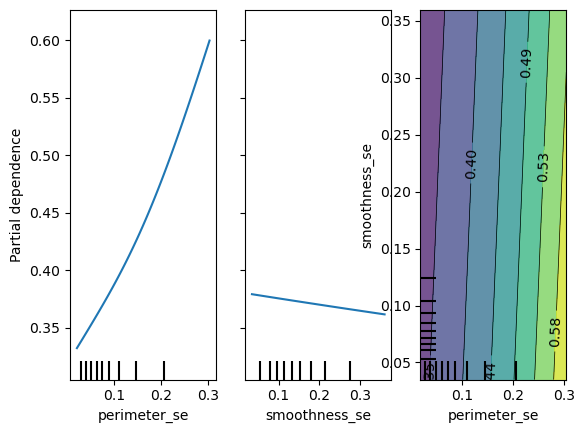

In [ ]:
from sklearn.inspection import PartialDependenceDisplay

features = ['perimeter_se', 'smoothness_se', ('perimeter_se', 'smoothness_se')]
PartialDependenceDisplay.from_estimator(model_corr, X_train_corr, features)

Мы видим, что чем больше стнадратная ошибка периметра ядер клеток (?), тем доля людей, которая со злом, а чем больше стандратная ошибка гладкости (локальное изменение длины радиуса), тем меньше доля людей получит зло.

Также  среднее значение целевой переменной (по сути это доля людей со злокачестввенным новообразованием) сильно увеличивается в правом нижнем углу, где большая гладкость и малый периметр (58% людей).

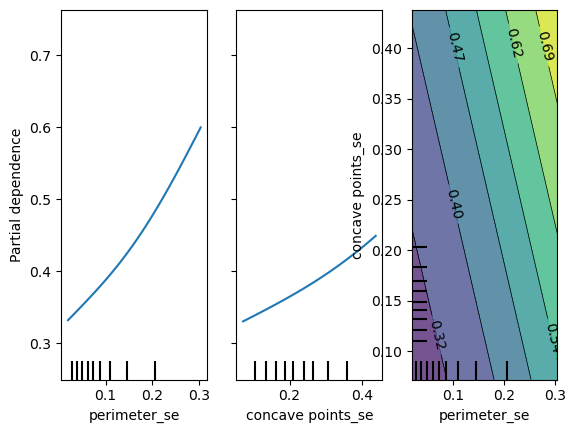

In [ ]:
features = ['perimeter_se', 'concave points_se', ('perimeter_se', 'concave points_se')]
PartialDependenceDisplay.from_estimator(model_corr, X_train_corr, features)

Попробуем с признаками, имеющие положительные веса. Тут видим, что при увеличении той же стандартной ошибки периметра и увеличении точки вогнутости (количество вогнутых участков контура) - доля людей со злом увеличивается

## SVM classifier

In [ ]:
from sklearn.svm import SVC

model_corr = SVC(probability=True)
model_corr.fit(X_train_corr, y_train_corr)

Accuracy_corr_SVM = accuracy_score(y_test_corr, model_corr.predict(X_test_corr))
F1_score_corr_SVM = f1_score(y_test_corr, model_corr.predict(X_test_corr))
ROC_AUC_corr_SVM = roc_auc_score(y_test_corr, model_corr.predict_proba(X_test_corr)[:, 1])

print('Accuracy SVM =', Accuracy_corr_SVM)
print('F1-score SVM =', F1_score_corr_SVM)
print('ROC AUC SVM =', ROC_AUC_corr_SVM)
print('')
print('Accuracy LR =', balanced_accuracy_score_LR)
print('F1-score LR =', f_score_LR_corr)
print('ROC AUC LR =', roc_auc_corr_LR)

Accuracy SVM = 0.9649122807017544
F1-score SVM = 0.951219512195122
ROC AUC SVM = 0.9973544973544974

Accuracy LR = 0.9692460317460317
F1-score LR = 0.963855421686747
ROC AUC LR = 0.9983465608465609


Видим, что SVM классификатор даёт прирост качества по всем метрикам, по сравнению с LR.  
`F1-score_corr = 0.90` и `Balanced accuracy LogisticRegression_arr = 0.914` и `ROC AUC = 0.959`.

## Подбор гиперпараметров модели на валидационной выборке.

У меня есть выборки train/test/valid которые я раннее сразу разделила на  обучающую (60%), валидационную (20%) и тестовую (20%). Эти данные стандартизованы, а также применем minmax scaler, но я оставила все признаки для эксперимента.  
Надо отделить данные на валидацию у того датасета, у которого я убрала высокоскоррелированные признаки.

In [ ]:
X_train_only, X_validation, y_train_only, y_validation = train_test_split(X_train_corr, y_train_corr,
                                                                          test_size=0.2,
                                                                          stratify=y_train_corr,
                                                                        random_state=RANDOM_STATE)

Обучим модель и проверим качество на валидации, но это не то качество, которое реально характеризует качество модели.

Посмотрим на два разных ядра модели ядра:  
*kernel{‘linear’, ‘poly’, ‘rbf’, ‘sigmoid’, ‘precomputed’} or callable, default=’rbf’*

In [ ]:
model_1 = SVC(probability=True, kernel='linear', random_state=RANDOM_STATE)
model_1.fit(X_train_only, y_train_only)
score_1_val = roc_auc_score(y_validation, model_1.predict_proba(X_validation)[:, 1])
print(f'SVC-linear, ROC AUC (validation): {score_1_val}')

SVC-linear, ROC AUC (validation): 0.9891640866873065


In [ ]:
model_2 = SVC(probability=True, kernel='rbf', random_state=RANDOM_STATE)
model_2.fit(X_train_only, y_train_only)
score_2_val = roc_auc_score(y_validation, model_2.predict_proba(X_validation)[:, 1])
print(f'SVC-RBF, ROC AUC (validation): {score_2_val}')

SVC-RBF, ROC AUC (validation): 0.9922600619195046


Есть небольшая разница в зависимости от ядра "linear" это или "rbf". Оставим ’rbf’, как и по дефолту (на ней валидация лучше). Проверяим на тестовой выборке.

In [ ]:
score_test_acc_SVM = roc_auc_score(y_test_corr, model_2.predict_proba(X_test_corr)[:, 1])
print(f'SVC final score, ROC AUC (test_corr): {score_test_acc_SVM}')

SVC final score, ROC AUC (test_corr): 0.9976851851851852


Попробуем построить модель SVM для данных, где я не удаляла признаки:

In [ ]:
model_1 = SVC(probability=True, kernel='linear', random_state=RANDOM_STATE)
model_1.fit(features_train, target_train)
score_1_val = roc_auc_score(target_valid, model_1.predict_proba(features_valid)[:, 1])
print(f'SVC-linear, ROC AUC (validation): {score_1_val}')

SVC-linear, ROC AUC (validation): 1.0


In [ ]:
model_2 = SVC(probability=True, kernel='rbf', random_state=RANDOM_STATE)
model_2.fit(features_train, target_train)
score_2_val = roc_auc_score(target_valid, model_2.predict_proba(features_valid)[:, 1])
print(f'SVC-RBF, ROC AUC (validation): {score_2_val}')

SVC-RBF, ROC AUC (validation): 0.9986772486772486


Также есть небольшая разница улучшения качества в сторону ядра linear.

In [ ]:
score_test_SVM = roc_auc_score(target_test, model_1.predict_proba(features_test)[:, 1])
print(f'SVC final score, ROC AUC (test): {score_test_SVM}')

SVC final score, ROC AUC (test): 0.9954143465443825


В итоге: Для выборок, где я поудаляла признаки - `SVC final score, ROC AUC (test_corr): 0.9976851851851852` у нас гиперпараметр kernel = "rbf" - лучшая модель. Для выборки, где я оставила все признаки - `SVC final score, ROC AUC (test): 0. 0.9954143465443825` у нас гиперпараметр kernel = "linear" - лучшая модель.

## DecisionTreeClassifier model

Раннее я уже разделила выборки на train и test датасет без стандартизации (это данные где я удалила скоррелированные признаки и не провела стандартизацию).  
Возможность построить решающее дерево не зависит от нормировки. А значения будут более интерпретируемые, если не переводить признаки в z-шкалу.

In [ ]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=RANDOM_STATE)
model.fit(X_train_tree, y_train_tree)

print('Accuracy', accuracy_score(y_test_tree, model.predict(X_test_tree)))
print('F1-score', f1_score(y_test_tree, model.predict(X_test_tree)))
print('ROC AUC', roc_auc_score(y_test_tree, model.predict_proba(X_test_tree)[:, 1]))

Accuracy 0.9298245614035088
F1-score 0.9
ROC AUC 0.9146825396825397


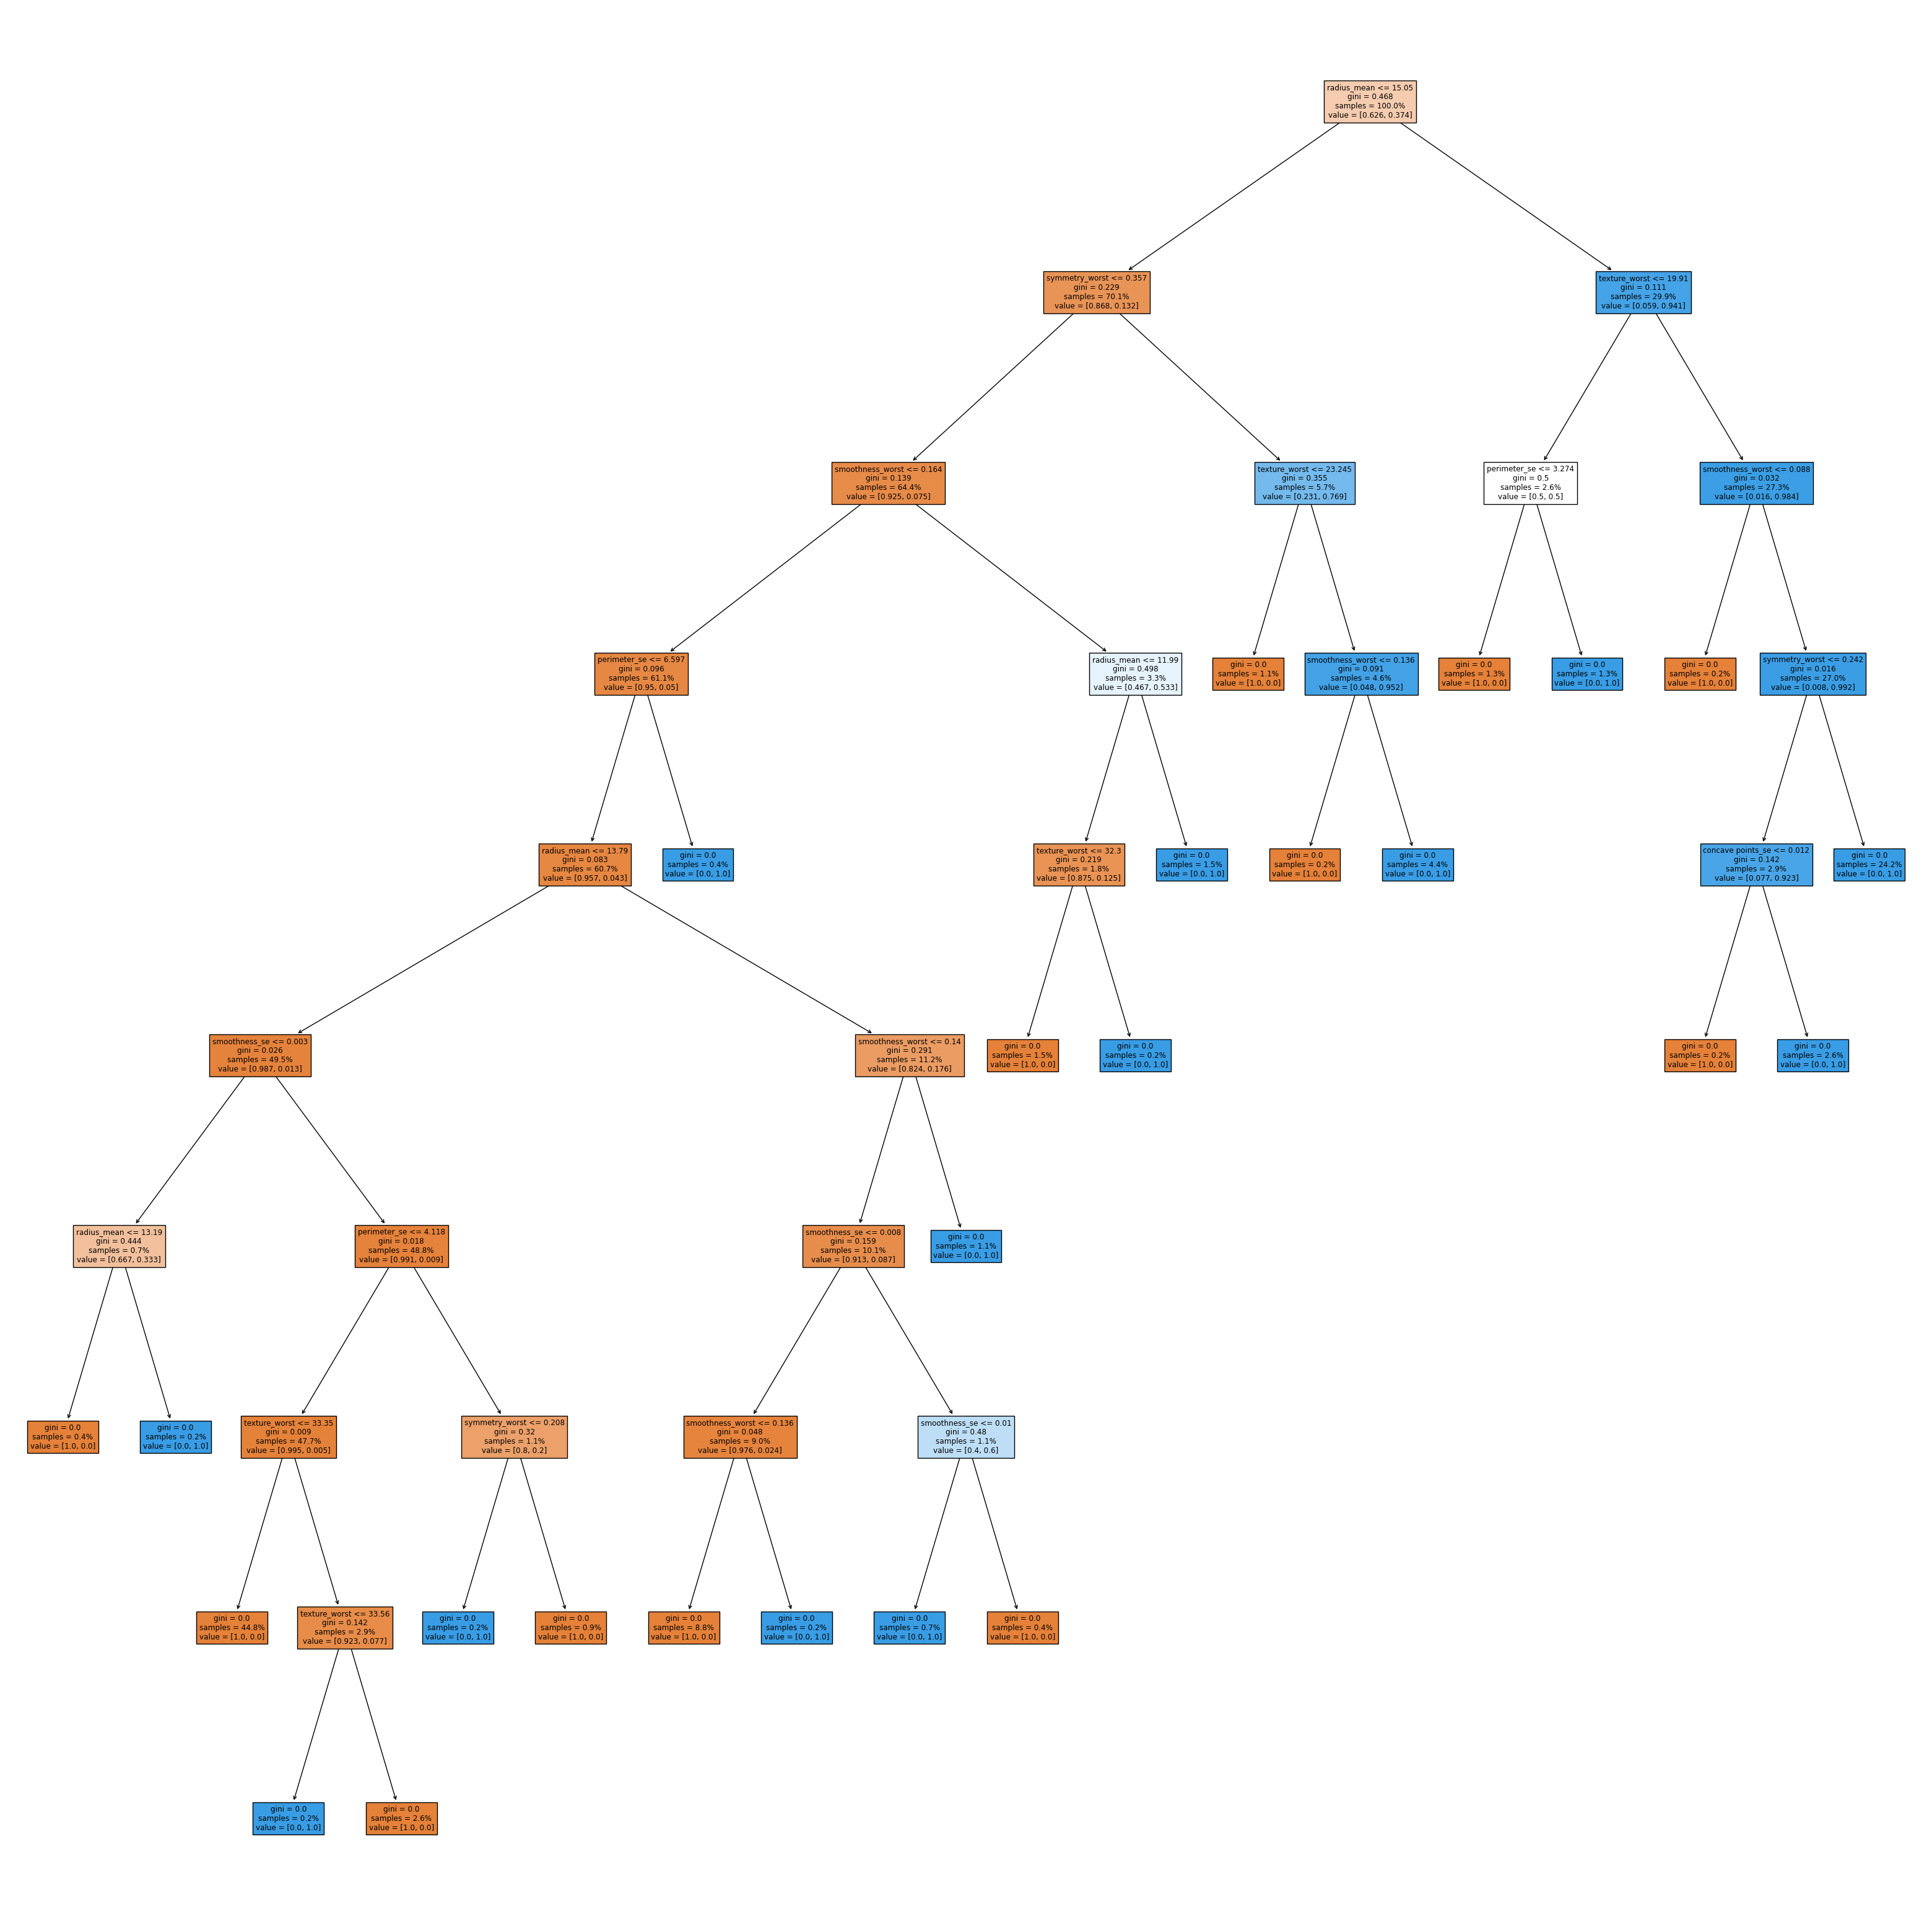

In [ ]:
from sklearn.tree import plot_tree

plt.figure(figsize=(40,40))
plot_tree(model, proportion=True, filled=True, feature_names=X_train_tree.columns)
plt.savefig('decision_tree.png')

Раскраска ячеек следующая:
* класс 0 (доброкач) — красный
* класс 1 (злокач) — синий.

## Проведем подбор гиперпараметров с помощью кроссвалидации

При помощи кроссвалидации подоберем лучший критерий деления узлов и максимальную глубину дерева.  
Разобьем на 25 кучек.

In [ ]:
455 / 25

18.2

По умолчанию стоит: *criterion='gini', max_depth=None*

In [ ]:
from sklearn.model_selection import cross_val_score

score_list = []
for depth in range(1,5):
    for criterion in ['gini', 'entropy', 'log_loss']:
        cv_results = cross_val_score(DecisionTreeClassifier(criterion=criterion, max_depth=depth),
                                     X_tree, y_tree, cv=25)
        mean = cv_results.mean()
        std = cv_results.std()
        score_list.append((mean, depth, criterion, std))
        best_params = max(score_list)


print(best_params)
#print(f'criterion: {criterion}; score = {mean} ± {std}; depth = {depth}')

(0.9245849802371541, 4, 'gini', 0.05561106099074674)


In [ ]:
score_list

[(0.8877470355731225, 1, 'gini', 0.07677757513953062),
 (0.8877470355731225, 1, 'entropy', 0.07677757513953062),
 (0.8877470355731225, 1, 'log_loss', 0.07677757513953062),
 (0.9037154150197628, 2, 'gini', 0.056024848135046726),
 (0.8984189723320157, 2, 'entropy', 0.06685803172959329),
 (0.8984189723320157, 2, 'log_loss', 0.06685803172959329),
 (0.9209486166007905, 3, 'gini', 0.06809899305701746),
 (0.9137549407114625, 3, 'entropy', 0.06760367821033204),
 (0.9155731225296444, 3, 'log_loss', 0.06683821346624365),
 (0.9245849802371541, 4, 'gini', 0.05561106099074674),
 (0.9086166007905139, 4, 'entropy', 0.06192877504659474),
 (0.9068774703557311, 4, 'log_loss', 0.0611648297855342)]

Я не понимаю, почему когда каждый раз при перезапуске всех ячеек, меняется score_list и соответственно все лучшие параметры. Когда то точность 0.92 при критерии эентропии и глубины дерева 6, когда то точность тоже 0.93 при критерии log_loss с глубиной тоже 6.  
Предположу, что критерии выглядят похоже и +- все одинаковы.  
Разбрас резльтатов разброс качества довольно большой (6.3 % либо чуть меньше 5%). Какой критерий лучше?  
Мы видим что разброс значений больше, чем разница между значениями.

Запишу лучшие метрики модели дерева в переменные

In [ ]:
model = DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth = 4, criterion = 'gini')
model.fit(X_train_tree, y_train_tree)

acc_DTC = accuracy_score(y_test_tree, model.predict(X_test_tree))
f_crore_DTC = f1_score(y_test_tree, model.predict(X_test_tree))
roc_auc_DTC = roc_auc_score(y_test_tree, model.predict_proba(X_test_tree)[:, 1])

print('Accuracy', acc_DTC)
print('F1-score', f_crore_DTC)
print('ROC AUC', roc_auc_DTC)

Accuracy 0.9210526315789473
F1-score 0.8831168831168832
ROC AUC 0.9001322751322752


In [ ]:
#model = DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth = None, criterion = 'gini')
#model.fit(X_train_tree, y_train_tree)

#acc_DTC = accuracy_score(y_test_tree, model.predict(X_test_tree))
#f_crore_DTC = f1_score(y_test_tree, model.predict(X_test_tree))
#roc_auc_DTC = roc_auc_score(y_test_tree, model.predict_proba(X_test_tree)[:, 1])

#print('Accuracy', acc_DTC)
#print('F1-score', f_crore_DTC)
#print('ROC AUC', roc_auc_DTC)

## RandomForestClassifier model

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train_tree, y_train_tree)
acc_RFC = accuracy_score(y_test_tree, model.predict(X_test_tree))
f_score_RFC = f1_score(y_test_tree, model.predict(X_test_tree))
roc_auc_RFC = roc_auc_score(y_test_tree, model.predict_proba(X_test_tree)[:, 1])

print('Accuracy', acc_RFC)
print('F1-score', f_score_RFC)
print('ROC AUC', roc_auc_RFC)

Accuracy 0.9649122807017544
F1-score 0.9500000000000001
ROC AUC 0.9953703703703703


Изучим значимости признаков.

In [ ]:
#model.feature_importances_

In [ ]:
dict(
    sorted(
        zip(model.feature_names_in_, model.feature_importances_),
        key=lambda kv: kv[1]
    )
)

{'fractal_dimension_se': 0.02203991803065351,
 'smoothness_se': 0.023721853496871406,
 'fractal_dimension_mean': 0.025192017808260338,
 'texture_se': 0.0258129857194676,
 'symmetry_se': 0.028899156097084173,
 'concave points_se': 0.06480879577782898,
 'symmetry_worst': 0.08316384071670962,
 'smoothness_worst': 0.10070914418667534,
 'texture_worst': 0.11177688040710183,
 'perimeter_se': 0.15361499580712393,
 'radius_mean': 0.36026041195222314}

Видим,что самые значимые признаки: `radius_mean` и `perimeter_se`, а менее значимые `fractal_dimension_se` и `fractal_dimension_mean`

Попробуем удалить не значимые признаки и обучить лес.

In [ ]:
X_test_tree_prob = X_test_tree.drop(['fractal_dimension_se', 'fractal_dimension_mean'], axis=1)
X_train_tree_prob = X_train_tree.drop(['fractal_dimension_se', 'fractal_dimension_mean'], axis=1)

In [ ]:
#X_test_tree_prob.columns

In [ ]:
model = RandomForestClassifier()
model.fit(X_train_tree_prob, y_train_tree)

print('Accuracy', accuracy_score(y_test_tree, model.predict(X_test_tree_prob)))
print('F1-score', f1_score(y_test_tree, model.predict(X_test_tree_prob)))
print('ROC AUC', roc_auc_score(y_test_tree, model.predict_proba(X_test_tree_prob)[:, 1]))

Accuracy 0.956140350877193
F1-score 0.9367088607594937
ROC AUC 0.9940476190476191


Качество толком не поменялось, ухудшилось F1-score и Accuracy. Значит вернем признаки обратно.

## Градиентный бустинг. XGBClassifier model

Возьмем данные, которые без нормировки (без стандартизации) и у которых удалены высоко коррелируюище между собой признаки.

In [ ]:
#! pip3 install xgboost

Большую глубину лучше не задавать - выскоа вероятность что дерево переобучится.

In [ ]:
from xgboost import XGBClassifier
model = XGBClassifier(n_estimators=100, max_depth=5)
model.fit(X_train_tree, y_train_tree)

print('Accuracy', accuracy_score(y_test_tree, model.predict(X_test_tree)))
print('F1-score', f1_score(y_test_tree, model.predict(X_test_tree)))
print('ROC AUC', roc_auc_score(y_test_tree, model.predict_proba(X_test_tree)[:, 1]))

Accuracy 0.9473684210526315
F1-score 0.925
ROC AUC 0.9914021164021164


Переберем гиперпараметры:

In [ ]:
best_model = None
best_result = 0
for depth in range(1,6):
    for est in [10, 15, 100, 150]:
        model = XGBClassifier(n_estimators=est, max_depth=depth)
        model.fit(X_train_tree, y_train_tree)
        acc_result = accuracy_score(y_test_tree, model.predict(X_test_tree))
        f1_result = f1_score(y_test_tree, model.predict(X_test_tree))
        roc_auc_relult = roc_auc_score(y_test_tree, model.predict_proba(X_test_tree)[:, 1])
        if f1_result > best_result:
            best_model = model
            best_result = f1_result

print("Результат F1-score на тестовой выборке", best_result)
print(' ')
print(best_model.get_params())

Результат F1-score на тестовой выборке 0.962962962962963
 
{'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': None, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': None, 'feature_types': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': None, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 2, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 100, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': None, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': None, 'tree_method': None, 'validate_parameters': None, 'verbosity': None}


In [ ]:
from xgboost import XGBClassifier
model = XGBClassifier(n_estimators=100, max_depth=2)
model.fit(X_train_tree, y_train_tree)
predictions_test_XGB = model.predict(X_test_tree)

print('Accuracy', accuracy_score(y_test_tree, model.predict(X_test_tree)))
print('F1-score', f1_score(y_test_tree, model.predict(X_test_tree)))
print('ROC AUC', roc_auc_score(y_test_tree, model.predict_proba(X_test_tree)[:, 1]))

Accuracy 0.9736842105263158
F1-score 0.962962962962963
ROC AUC 0.9930555555555556


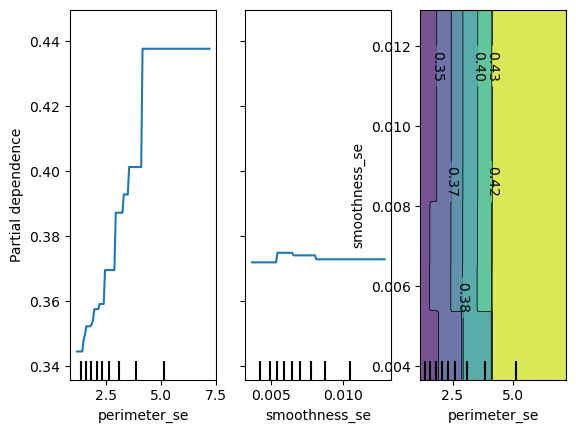

In [ ]:
from sklearn.inspection import PartialDependenceDisplay

model = XGBClassifier(n_estimators=100, max_depth=2)
model.fit(X_train_tree, y_train_tree)
features = ['perimeter_se', 'smoothness_se', ('perimeter_se', 'smoothness_se')]
PartialDependenceDisplay.from_estimator(model, X_train_tree, features)


Так же видим, что и ранее: "Мы видим, что чем больше стнадратная ошибка периметра ядер клеток (?), тем доля людей, которая со злом, а чем больше стандратная ошибка гладкости (локальное изменение длины радиуса), тем меньше доля людей получит зло."

In [ ]:
acc_XGB = accuracy_score(y_test_tree, model.predict(X_test_tree))
f_score_XGB = f1_score(y_test_tree, model.predict(X_test_tree))
roc_auc_XGB = roc_auc_score(y_test_tree, model.predict_proba(X_test_tree)[:, 1])

# Вывод

Таким образом, соберем все модели, все их метрики вместе. Метрики расчитаны на тестовой выборке.

Сравнение моделей, где я удаляла признаки применив корреляцию Пирсона, убрав мультиколлинеарные признаки.

In [ ]:
# Логистическая регрессия
print('Лучшие модели с подобранными гиперпараметрами')
print("")
print('Логистическая регрессия: cs=100')
print('Accuracy balanced LR =', balanced_accuracy_score_LR)
print('F1-score LR =', f_score_LR_corr)
print('ROC AUC LR =', roc_auc_corr_LR)
#print('PR AUC LR', pr_auc_corr_LR)
print("")

# SVM
print('Машины опорных векторов: kernel="rbf"')
print('Accuracy SVM =', Accuracy_corr_SVM)
print('F1-score SVM =', F1_score_corr_SVM)
print('ROC AUC SVM =', ROC_AUC_corr_SVM)
print("")
# DecisionTreeClassifier
print('Дерево решений: max_depth = 4, criterion = "gini"')
print('Accuracy DTC =', acc_DTC)
print('F1-score DTC =', f_crore_DTC)
print('ROC AUC DTC =', roc_auc_DTC)
print("")

# RandomForestClassifier
print('Случайный лес: гиперпараметры по дефолту (не подбирала)')
print('Accuracy RFC =', acc_RFC)
print('F1-score RFC =', f_score_RFC)
print('ROC AUC RFC =', roc_auc_RFC)
print("")

# XGBClassifier
print('Экстремальный градиентный бустинг: max_depth = 2, n_estimators = 100')
print('Accuracy XGB =', acc_XGB)
print('F1-score XGB =', f_score_XGB)
print('ROC AUC XGB =', roc_auc_XGB)

Лучшие модели с подобранными гиперпараметрами

Логистическая регрессия: cs=100
Accuracy balanced LR = 0.9692460317460317
F1-score LR = 0.963855421686747
ROC AUC LR = 0.9983465608465609

Машины опорных векторов: kernel="rbf"
Accuracy SVM = 0.9649122807017544
F1-score SVM = 0.951219512195122
ROC AUC SVM = 0.9973544973544974

Дерево решений: max_depth = 4, criterion = "gini"
Accuracy DTC = 0.9210526315789473
F1-score DTC = 0.8831168831168832
ROC AUC DTC = 0.9001322751322752

Случайный лес: гиперпараметры по дефолту (не подбирала)
Accuracy RFC = 0.9649122807017544
F1-score RFC = 0.9500000000000001
ROC AUC RFC = 0.9953703703703703

Экстремальный градиентный бустинг: max_depth = 2, n_estimators = 100
Accuracy XGB = 0.9736842105263158
F1-score XGB = 0.962962962962963
ROC AUC XGB = 0.9930555555555556


Дерево решений показало наихудшие метрики, самые высокие у градиентного бустинга. Но нужно модель проверить на переобучение, так как она к этому чувтсвительная.  
Градиентный бустинг, лучше дерева решений, например, так как в градиентном бустинге деревья решений строятся последовательно, где каждое обучается исправлять ошибки, допущенные предыдущими. Случайный лес, например, использует большинство голосов для прогнозирования результата, что может потребовать большего количества деревьев для достижения того же уровня точности.

[[72  0]
 [ 3 39]]


Text(50.722222222222214, 0.5, 'Actual')

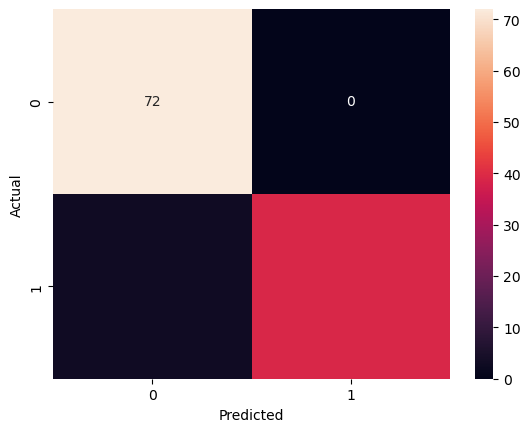

In [ ]:
conf_matrix_XGB = confusion_matrix(y_test_tree, predictions_test_XGB)
print(conf_matrix_XGB) #  сначала идут истинные значение, затем предсказанные

sns.heatmap(conf_matrix_XGB, annot=True)
plt.xlabel('Predicted') # По оси Y идёт реальная метка класса, по оси X — предсказанная.
plt.ylabel('Actual')

По матрице ошибок видим, что модель градиентного бустинга: из 72 человек предсказала корректно/верно (добро было, добро и предсказано) (TN), 0 человек (FP) - предсказала что зло, а на самом деле было добро.
Есть злокачественное новообразование молочки у 3х человек - и 3 (FN) человека не были предсказаны что у них зло, а 39 (TP) человек были предсказаны, что есть злокач. рак он и был.  